In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

In [7]:
df = pd.read_csv("group_31_train.csv")

In [167]:
# =========================
# 1. آگاهی کلی از دیتاست
# =========================

print("Shape of data:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values summary:")
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
}).sort_values("missing_percent", ascending=False)

display(missing_summary)

Shape of data: (100000, 35)

Column names:
['f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17', 'f18', 'f19', 'f20', 'f21', 'f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30', 'f31', 'f32', 'f33', 'f34', 'y']

Data types:


,dtype
f1,object
f2,object
f3,float64
f4,float64
f5,float64
f6,float64
f7,object
f8,object
f9,object
f10,object



Missing values summary:


,missing_count,missing_percent
f4,43853,43.853
f5,43853,43.853
f20,28806,28.806
f19,7498,7.498
f18,2276,2.276
f16,2208,2.208
f17,1812,1.812
f15,1533,1.533
f14,304,0.304
f32,290,0.290


In [168]:
# =========================
# 2. بررسی ستون‌های categorical / object / bool و ستون هدف y
# =========================

target_col = "y"

categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

if target_col in df.columns and target_col not in categorical_cols:
    categorical_cols = [target_col] + categorical_cols

print("Categorical / Object / Bool columns:")
print(categorical_cols)

categorical_summary = []

for col in categorical_cols:
    categorical_summary.append({
        "column": col,
        "dtype": df[col].dtype,
        "unique_count": df[col].nunique(dropna=True),
        "missing_count": df[col].isna().sum(),
        "missing_percent": df[col].isna().mean() * 100
    })

categorical_summary = pd.DataFrame(categorical_summary)
display(categorical_summary.sort_values("unique_count", ascending=False))


# نمایش مقادیر یکتا و تعداد هر مقدار برای ستون‌های categorical
for col in categorical_cols:
    print("=" * 80)
    print(f"Column: {col}")
    print(f"Unique values count: {df[col].nunique(dropna=True)}")
    print(f"Missing values: {df[col].isna().sum()}")
    
    display(
        df[col]
        .value_counts(dropna=False)
        .to_frame("count")
        .assign(percent=lambda x: x["count"] / len(df) * 100)
    )


Categorical / Object / Bool columns:
['y', 'f1', 'f2', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f18', 'f21', 'f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30', 'f31', 'f32', 'f33', 'f34']


,column,dtype,unique_count,missing_count,missing_percent
2,f2,object,99438,0,0.000
3,f7,object,92402,0,0.000
11,f15,object,78150,1533,1.533
8,f12,object,36832,30,0.030
4,f8,object,32350,140,0.140
5,f9,object,6292,2,0.002
10,f14,object,1596,304,0.304
6,f10,object,1279,0,0.000
7,f11,object,49,0,0.000
12,f18,object,24,2276,2.276


Column: y
Unique values count: 4
Missing values: 0


,count,percent
y,,
2,79621,79.621
3,16871,16.871
4,2631,2.631
1,877,0.877


Column: f1
Unique values count: 3
Missing values: 0


...

,count,percent
f32,,
Day,69081,69.081
Night,30629,30.629
NaN,290,0.290


Column: f33
Unique values count: 2
Missing values: 290


,count,percent
f33,,
Day,78645,78.645
Night,21065,21.065
NaN,290,0.290


Column: f34
Unique values count: 2
Missing values: 290


,count,percent
f34,,
Day,82519,82.519
Night,17191,17.191
NaN,290,0.290


In [169]:
# =========================
# 3. بررسی ستون‌های عددی
# =========================

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("Numeric columns:")
print(numeric_cols)

numeric_summary = df[numeric_cols].describe().T
numeric_summary["missing_count"] = df[numeric_cols].isna().sum()
numeric_summary["missing_percent"] = df[numeric_cols].isna().mean() * 100
numeric_summary["unique_count"] = df[numeric_cols].nunique()

display(numeric_summary)


Numeric columns:
['f3', 'f4', 'f5', 'f6', 'f16', 'f17', 'f19', 'f20', 'y']


,count,mean,std,min,25%,50%,75%,max,missing_count,missing_percent,unique_count
f3,100000.0,-94.626222,17.362053,-124.433974,-117.172629,-87.709000,-80.351696,-68.658240,0,0.000,90693
f4,56147.0,36.284028,5.293667,24.587816,33.462228,36.269916,40.209354,49.000769,43853,43.853,51866
f5,56147.0,-95.595153,18.080980,-124.458254,-117.689249,-87.946400,-80.241058,-68.658240,43853,43.853,51909
f6,100000.0,0.557936,1.749662,0.000000,0.000000,0.031000,0.460000,112.968000,0,0.000,6108
f16,97792.0,64.746615,22.882070,1.000000,48.000000,67.000000,84.000000,100.000000,2208,2.208,99
f17,98188.0,29.540512,1.010039,9.900000,29.370000,29.860000,30.030000,58.390000,1812,1.812,857
f19,92502.0,7.670945,5.301164,0.000000,4.600000,7.000000,10.400000,142.000000,7498,7.498,77
f20,71194.0,0.007989,0.095359,0.000000,0.000000,0.000000,0.000000,10.040000,28806,28.806,114
y,100000.0,2.212560,0.487381,1.000000,2.000000,2.000000,2.000000,4.000000,0,0.000,4


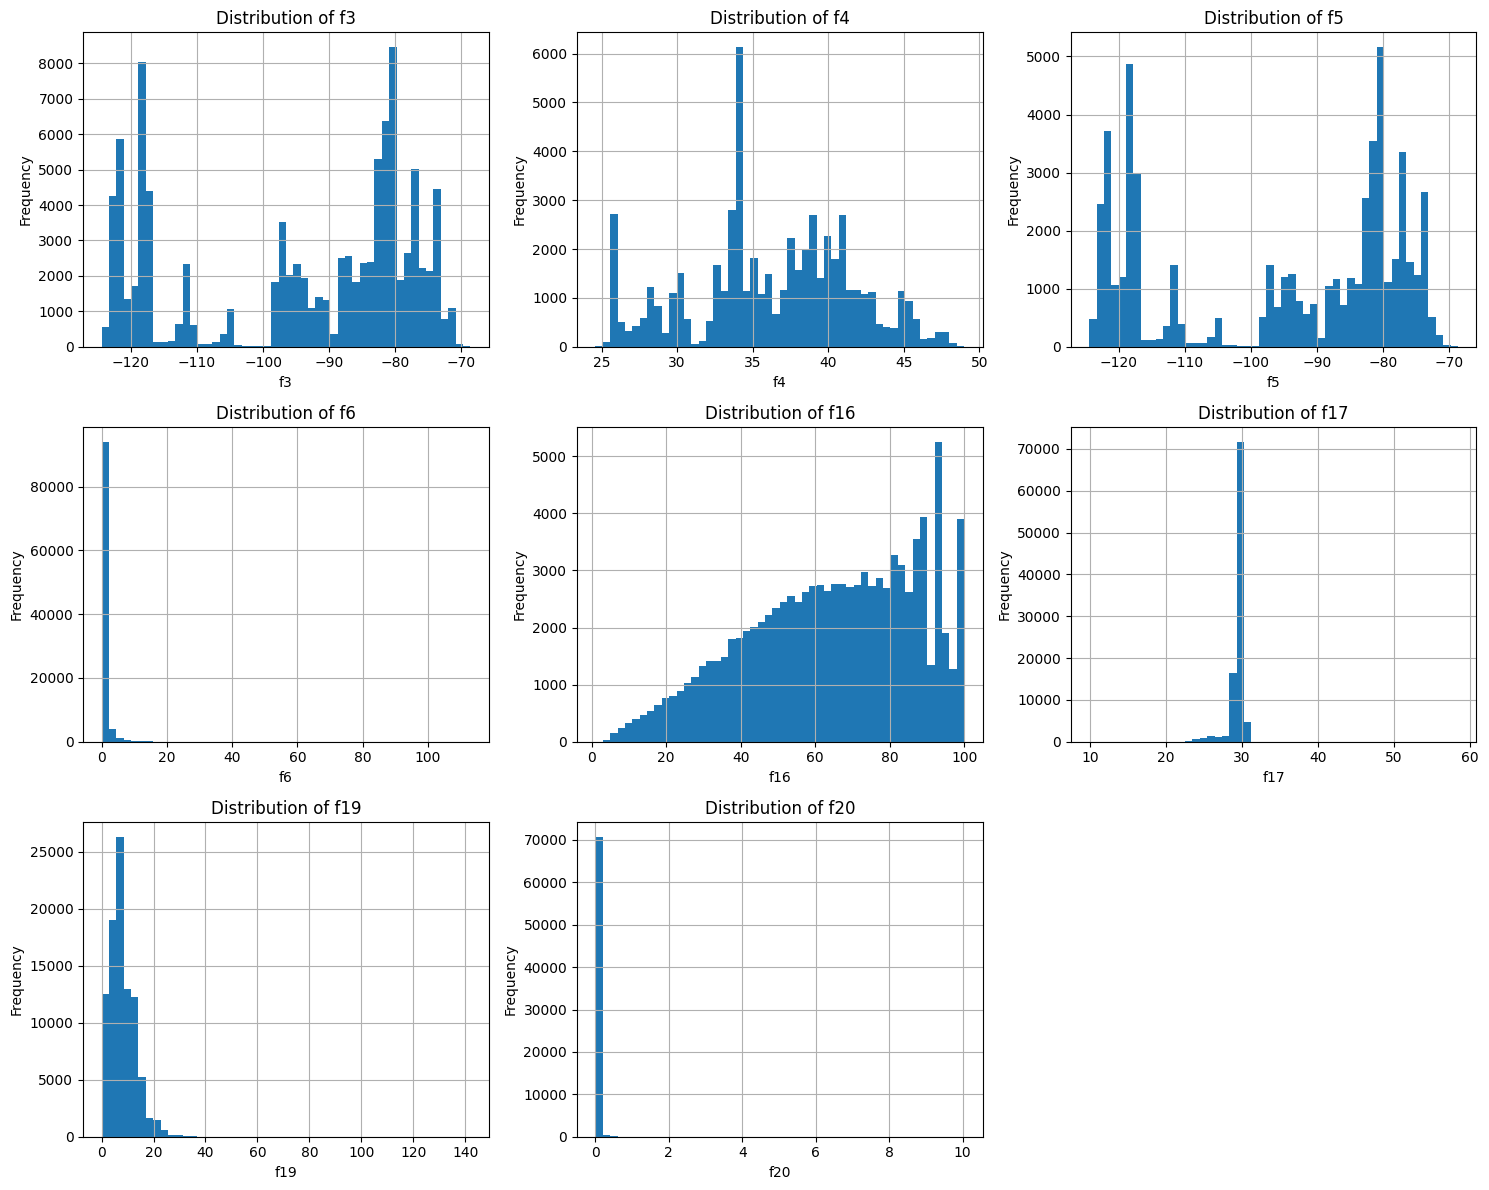

In [170]:
# =========================
# 4. رسم نمودار توزیع ستون‌های عددی
# =========================

numeric_cols_for_plot = [col for col in numeric_cols if col != target_col]

n_cols = 3
n_rows = math.ceil(len(numeric_cols_for_plot) / n_cols)

plt.figure(figsize=(5 * n_cols, 4 * n_rows))

for i, col in enumerate(numeric_cols_for_plot, 1):
    plt.subplot(n_rows, n_cols, i)
    df[col].dropna().hist(bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

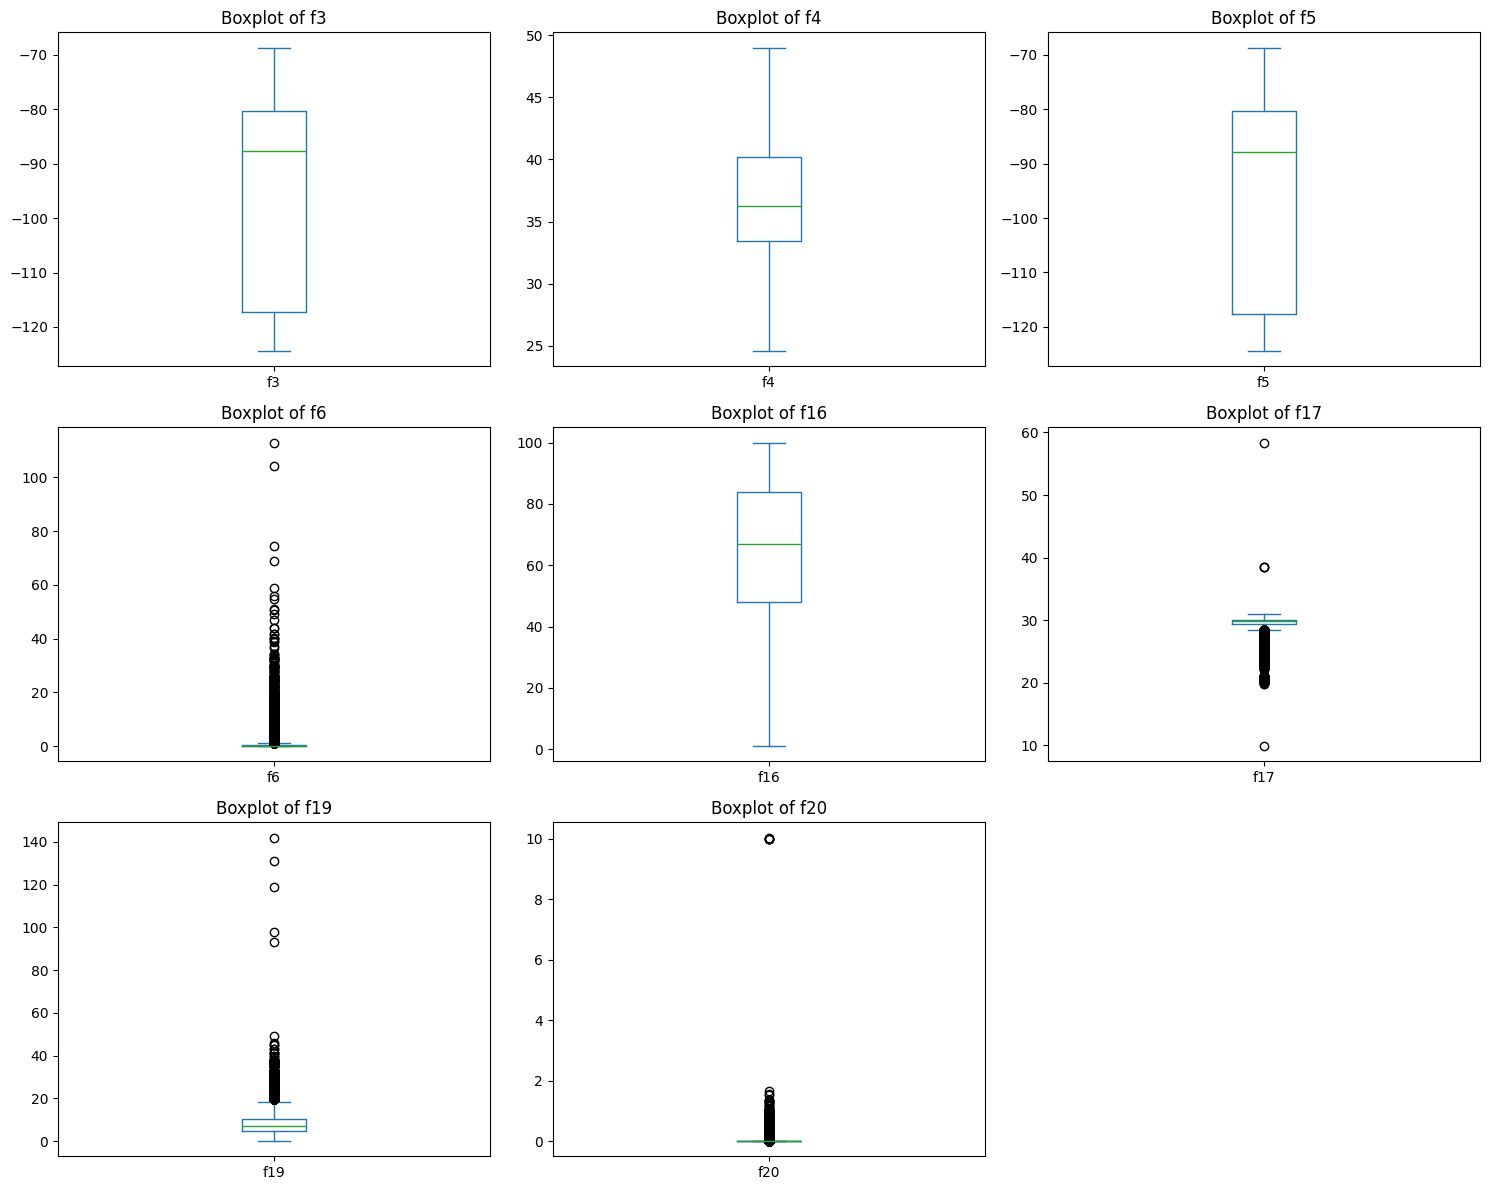

In [171]:
# =========================
# 5. رسم Boxplot برای تشخیص اولیه outlierها
# =========================

plt.figure(figsize=(5 * n_cols, 4 * n_rows))

for i, col in enumerate(numeric_cols_for_plot, 1):
    plt.subplot(n_rows, n_cols, i)
    df[col].dropna().plot(kind="box")
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

Target distribution:


,count,percent
y,,
2,79621,79.621
3,16871,16.871
4,2631,2.631
1,877,0.877


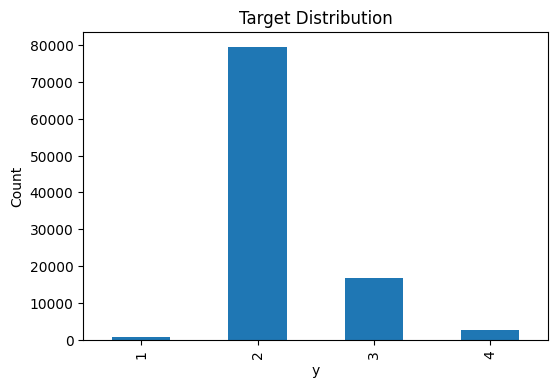

In [172]:
# =========================
# 6. بررسی توزیع ستون هدف y
# =========================

if target_col in df.columns:
    print("Target distribution:")
    target_dist = (
        df[target_col]
        .value_counts(dropna=False)
        .to_frame("count")
        .assign(percent=lambda x: x["count"] / len(df) * 100)
    )
    display(target_dist)

    plt.figure(figsize=(6, 4))
    df[target_col].value_counts().sort_index().plot(kind="bar")
    plt.title("Target Distribution")
    plt.xlabel(target_col)
    plt.ylabel("Count")
    plt.show()

In [173]:
# =========================
# Train/Test Split بدون sklearn
# Stratified Random Split based on y
# =========================

test_size = 0.2
random_state = 42
target_col = "y"

# اگر df قبلاً در نوت‌بوک تعریف نشده باشد
try:
    df
except NameError:
    df = pd.read_csv("/mnt/data/group_31_train.csv")

# برای اینکه ترتیب اولیه داده اثری نداشته باشد
df_shuffled = df.sample(frac=1, random_state=random_state)

# ساخت test به صورت stratified بر اساس درصد مشخص از هر کلاس y
test = (
    df_shuffled
    .groupby(target_col, group_keys=False)
    .sample(frac=test_size, random_state=random_state)
)

# باقی داده‌ها برای train
train = df_shuffled.drop(test.index)

# مرتب‌سازی مجدد indexها
train = train.reset_index(drop=True)
test = test.reset_index(drop=True)

# بررسی اندازه train و test
print("Train shape:", train.shape)
print("Test shape:", test.shape)

# بررسی توزیع کلاس‌ها در کل داده، train و test
class_distribution = pd.DataFrame({
    "original_count": df[target_col].value_counts().sort_index(),
    "original_percent": df[target_col].value_counts(normalize=True).sort_index() * 100,
    "train_count": train[target_col].value_counts().sort_index(),
    "train_percent": train[target_col].value_counts(normalize=True).sort_index() * 100,
    "test_count": test[target_col].value_counts().sort_index(),
    "test_percent": test[target_col].value_counts(normalize=True).sort_index() * 100
})

display(class_distribution)

Train shape: (80001, 35)
Test shape: (19999, 35)


,original_count,original_percent,train_count,train_percent,test_count,test_percent
y,,,,,,
1,877,0.877,702,0.877489,175,0.875044
2,79621,79.621,63697,79.620255,15924,79.623981
3,16871,16.871,13497,16.871039,3374,16.870844
4,2631,2.631,2105,2.631217,526,2.630132


In [174]:
print("\nMissing values summary:")
missing_summary = pd.DataFrame({
    "missing_count": train.isna().sum(),
    "missing_percent": train.isna().mean() * 100
}).sort_values("missing_percent", ascending=False)

display(missing_summary)


Missing values summary:


,missing_count,missing_percent
f4,35098,43.871952
f5,35098,43.871952
f20,23109,28.885889
f19,6058,7.572405
f18,1796,2.244972
f16,1762,2.202472
f17,1433,1.791228
f15,1211,1.513731
f14,240,0.299996
f32,218,0.272497


In [175]:
# ============================================================
# Missing Data Handling
# فرض: train و test در مرحله قبل ساخته شده‌اند.
# نکته مهم:
# تمام مقادیر جایگزین از train محاسبه می‌شوند
# و سپس همان تصمیم‌ها روی test اعمال می‌شوند.
# این کار برای جلوگیری از Data Leakage است.
# ============================================================


# ============================================================
# 0. کپی گرفتن از train و test برای اینکه نسخه خام از بین نرود
# ============================================================

train_processed = train.copy()
test_processed = test.copy()

In [176]:

# ============================================================
# 1. حذف f4 و f5
# دلیل:
# f4 و f5 حدود 44 درصد missing دارند.
# این missing بودن تصادفی نیست و به Source وابسته است.
# پس پر کردن آن‌ها با مقدار مصنوعی می‌تواند نویز یا bias ایجاد کند.
# ============================================================

cols_to_drop = ["f4", "f5"]

train_processed = train_processed.drop(columns=cols_to_drop, errors="ignore")
test_processed = test_processed.drop(columns=cols_to_drop, errors="ignore")

In [177]:
# ============================================================
# 2. f9: حذف ردیف‌هایی که City ندارند
# دلیل:
# تعداد missing در f9 بسیار کم است.
# پس حذف این چند ردیف آسیب جدی به داده نمی‌زند.
# ============================================================

print("Missing f9 in train before drop:", train_processed["f9"].isna().sum())
print("Missing f9 in test before drop:", test_processed["f9"].isna().sum())

train_processed = train_processed.dropna(subset=["f9"]).reset_index(drop=True)
test_processed = test_processed.dropna(subset=["f9"]).reset_index(drop=True)

print("Missing f9 in train after drop:", train_processed["f9"].isna().sum())
print("Missing f9 in test after drop:", test_processed["f9"].isna().sum())

Missing f9 in train before drop: 1
Missing f9 in test before drop: 1
Missing f9 in train after drop: 0
Missing f9 in test after drop: 0


f20 missing count in train: 23109
f20 missing percent in train: 28.886250000000004

f20 descriptive statistics:


count    56891.000000
mean         0.007976
std          0.103828
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         10.040000
Name: f20, dtype: float64


f20 value counts for most frequent values:


f20
0.00    51461
NaN     23109
0.01     1512
0.02      781
0.03      530
0.04      392
0.05      299
0.06      261
0.07      209
0.08      165
0.10      138
0.09      126
0.11      113
0.12       94
0.14       67
0.13       66
0.17       53
0.16       51
0.15       49
0.18       34
Name: count, dtype: int64

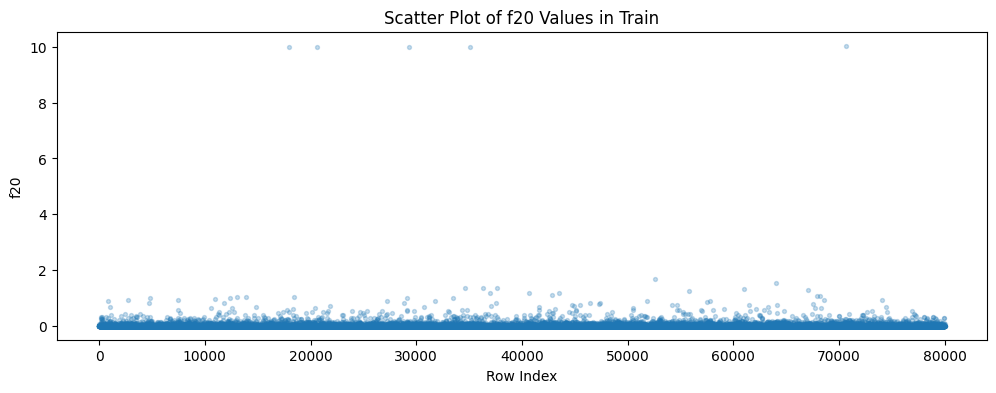

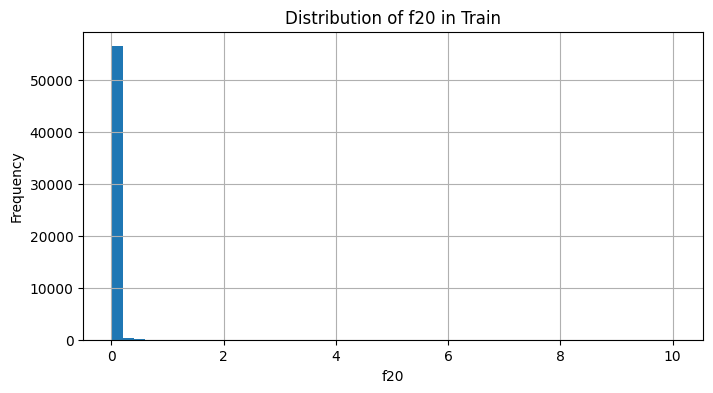

f20 missing count in train after fill: 0
f20 missing count in test after fill: 0


In [178]:
# ============================================================
# 3. f20: بررسی توزیع و سپس پر کردن missing با صفر
# f20 احتمالاً مربوط به میزان بارش است.
# در این نوع feature، مقدار 0 بسیار معنادار است.
# اگر توزیع نشان دهد داده‌ها zero-heavy هستند،
# پر کردن missing با 0 تصمیم قابل دفاعی است.
# ============================================================

print("f20 missing count in train:", train_processed["f20"].isna().sum())
print("f20 missing percent in train:", train_processed["f20"].isna().mean() * 100)

print("\nf20 descriptive statistics:")
display(train_processed["f20"].describe())

print("\nf20 value counts for most frequent values:")
display(train_processed["f20"].value_counts(dropna=False).head(20))

# نمودار پراکندگی مقدارهای f20
plt.figure(figsize=(12, 4))
plt.scatter(
    train_processed.index,
    train_processed["f20"],
    alpha=0.25,
    s=8
)
plt.title("Scatter Plot of f20 Values in Train")
plt.xlabel("Row Index")
plt.ylabel("f20")
plt.show()

# نمودار histogram برای دیدن توزیع f20
plt.figure(figsize=(8, 4))
train_processed["f20"].dropna().hist(bins=50)
plt.title("Distribution of f20 in Train")
plt.xlabel("f20")
plt.ylabel("Frequency")
plt.show()

# پر کردن مقدارهای خالی f20 با صفر
train_processed["f20"] = train_processed["f20"].fillna(0)
test_processed["f20"] = test_processed["f20"].fillna(0)

print("f20 missing count in train after fill:", train_processed["f20"].isna().sum())
print("f20 missing count in test after fill:", test_processed["f20"].isna().sum())



In [179]:
# ============================================================
# 4. تابع کمکی برای پر کردن عددی‌ها با ترکیب:
# global mode + state mean
#
# ایده:
# اگر برای یک ایالت داده زیادی داشته باشیم، به میانگین همان ایالت بیشتر اعتماد می‌کنیم.
# اگر برای یک ایالت داده کمی داشته باشیم، مقدار جایگزین بیشتر به global mode نزدیک می‌شود.
#
# weight = n_state / (n_state + smoothing)
#
# مقدار جایگزین:
# imputed_value = weight * state_mean + (1 - weight) * global_mode
#
# smoothing هرچقدر بزرگ‌تر باشد، اثر global mode بیشتر می‌شود.
# ============================================================

def plot_state_mean_distribution(df, col, state_col="f11", top_n=30):
    """
    این تابع نشان می‌دهد که میانگین feature عددی در ایالت‌های مختلف متفاوت است یا نه.
    برای خواناتر شدن نمودار، فقط top_n ایالت از نظر تعداد داده غیرخالی نمایش داده می‌شود.
    """
    state_stats = (
        df
        .dropna(subset=[col])
        .groupby(state_col)[col]
        .agg(["count", "mean"])
        .sort_values("count", ascending=False)
    )
    
    display(state_stats.sort_values("mean", ascending=False))
    
    top_states = state_stats.head(top_n).sort_values("mean", ascending=False)
    
    plt.figure(figsize=(12, 5))
    plt.bar(top_states.index.astype(str), top_states["mean"])
    plt.title(f"State-level Mean of {col} in Train")
    plt.xlabel("State")
    plt.ylabel(f"Mean of {col}")
    plt.xticks(rotation=45)
    plt.show()
    
    plt.figure(figsize=(12, 5))
    plt.bar(top_states.index.astype(str), top_states["count"])
    plt.title(f"Available Non-Missing Count of {col} by State in Train")
    plt.xlabel("State")
    plt.ylabel("Non-Missing Count")
    plt.xticks(rotation=45)
    plt.show()
    
    return state_stats


def fit_state_shrinkage_values(df, col, state_col="f11", smoothing=100):
    """
    این تابع فقط روی train اجرا می‌شود.
    خروجی آن شامل:
    - global_mode
    - میانگین هر ایالت
    - تعداد داده موجود در هر ایالت
    - وزن اثر هر ایالت
    - مقدار نهایی جایگزین برای missing های هر ایالت
    """
    global_mode = df[col].mode(dropna=True).iloc[0]
    
    state_stats = (
        df
        .dropna(subset=[col])
        .groupby(state_col)[col]
        .agg(["count", "mean"])
        .rename(columns={"count": "state_non_missing_count", "mean": "state_mean"})
    )
    
    state_stats["state_effect_weight"] = (
        state_stats["state_non_missing_count"] /
        (state_stats["state_non_missing_count"] + smoothing)
    )
    
    state_stats["global_mode_weight"] = 1 - state_stats["state_effect_weight"]
    
    state_stats["impute_value"] = (
        state_stats["state_effect_weight"] * state_stats["state_mean"] +
        state_stats["global_mode_weight"] * global_mode
    )
    
    return global_mode, state_stats


def apply_state_shrinkage_imputation(df, col, state_stats, global_mode, state_col="f11"):
    """
    این تابع missing های col را با مقدار shrinkage مربوط به ایالت پر می‌کند.
    اگر ایالتی در test وجود داشته باشد که در train نبوده،
    با global_mode پر می‌شود.
    """
    result = df.copy()
    
    state_to_impute_value = state_stats["impute_value"]
    
    missing_mask = result[col].isna()
    
    result.loc[missing_mask, col] = (
        result.loc[missing_mask, state_col]
        .map(state_to_impute_value)
        .fillna(global_mode)
    )
    
    return result



Analysis for f19
f19 missing count in train before fill: 6058
f19 missing percent in train before fill: 7.5725


count    73942.000000
mean         7.675352
std          5.323398
min          0.000000
25%          4.600000
50%          7.000000
75%         10.400000
max        142.000000
Name: f19, dtype: float64

,count,mean
f11,,
SD,3,20.666667
ND,28,14.285714
WY,27,14.174074
IA,253,10.913834
OK,813,10.872448
IL,1728,9.746470
NE,277,9.698556
MA,604,9.485099
RI,155,9.481290


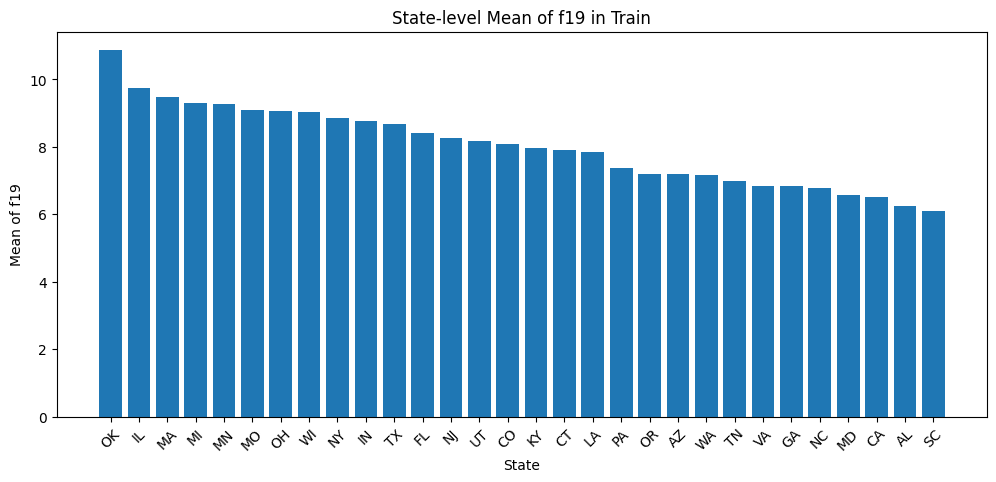

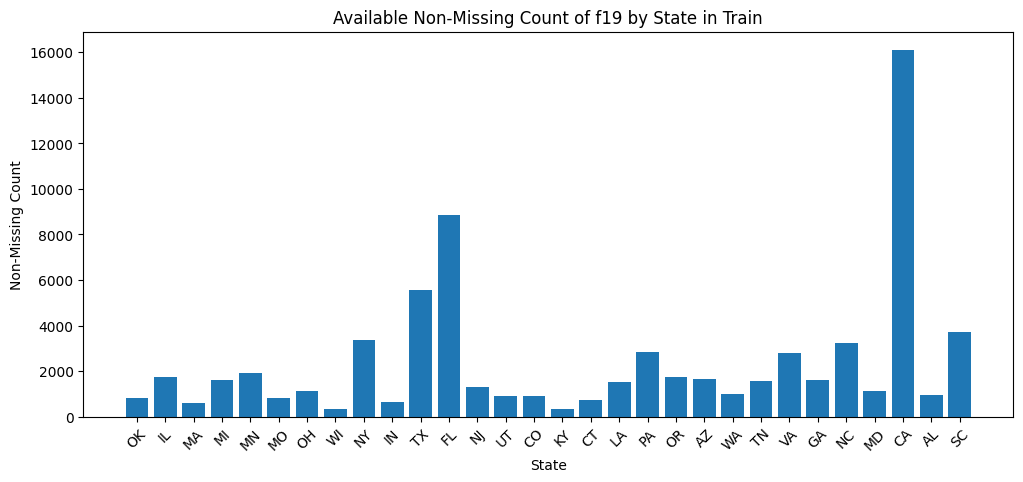

Global mode for f19: 0.0

State effect table for f19:


,state_non_missing_count,state_mean,state_effect_weight,global_mode_weight,impute_value
f11,,,,,
CA,16102,6.520022,0.993828,0.006172,6.479780
FL,8844,8.403539,0.988819,0.011181,8.309582
TX,5554,8.668977,0.982313,0.017687,8.515653
SC,3722,6.103117,0.973836,0.026164,5.943433
NY,3373,8.868248,0.971206,0.028794,8.612900
NC,3239,6.789503,0.970051,0.029949,6.586164
PA,2840,7.358486,0.965986,0.034014,7.108197
VA,2816,6.838849,0.965706,0.034294,6.604321
MN,1900,9.284053,0.950000,0.050000,8.819850


f19 missing count in train after fill: 0
f19 missing count in test after fill: 0


In [180]:
# ============================================================
# 5. f19: بررسی تفاوت ایالت‌ها و پر کردن missing با shrinkage
# f19 عددی است.
# طبق تصمیم:
# مقدار جایگزین ترکیبی از global mode و میانگین همان ایالت است.
# ============================================================

col = "f19"

print("\n" + "=" * 80)
print(f"Analysis for {col}")

print(f"{col} missing count in train before fill:", train_processed[col].isna().sum())
print(f"{col} missing percent in train before fill:", train_processed[col].isna().mean() * 100)

display(train_processed[col].describe())

f19_state_raw_stats = plot_state_mean_distribution(
    train_processed,
    col=col,
    state_col="f11",
    top_n=30
)

f19_global_mode, f19_state_stats = fit_state_shrinkage_values(
    train_processed,
    col=col,
    state_col="f11",
    smoothing=100
)

print(f"Global mode for {col}:", f19_global_mode)

print(f"\nState effect table for {col}:")
display(
    f19_state_stats
    .sort_values("state_effect_weight", ascending=False)
)

train_processed = apply_state_shrinkage_imputation(
    train_processed,
    col=col,
    state_stats=f19_state_stats,
    global_mode=f19_global_mode,
    state_col="f11"
)

test_processed = apply_state_shrinkage_imputation(
    test_processed,
    col=col,
    state_stats=f19_state_stats,
    global_mode=f19_global_mode,
    state_col="f11"
)

print(f"{col} missing count in train after fill:", train_processed[col].isna().sum())
print(f"{col} missing count in test after fill:", test_processed[col].isna().sum())


Analysis for f16
f16 missing count in train before fill: 1762
f16 missing percent in train before fill: 2.2025


count    78238.000000
mean        64.755771
std         22.874771
min          1.000000
25%         48.000000
50%         67.000000
75%         84.000000
max        100.000000
Name: f16, dtype: float64

,count,mean
f11,,
VT,15,84.133333
ME,27,78.148148
SD,3,76.666667
ND,29,73.448276
IN,666,72.914414
WA,1104,72.239130
OH,1205,72.054772
WV,129,71.883721
NH,118,71.813559


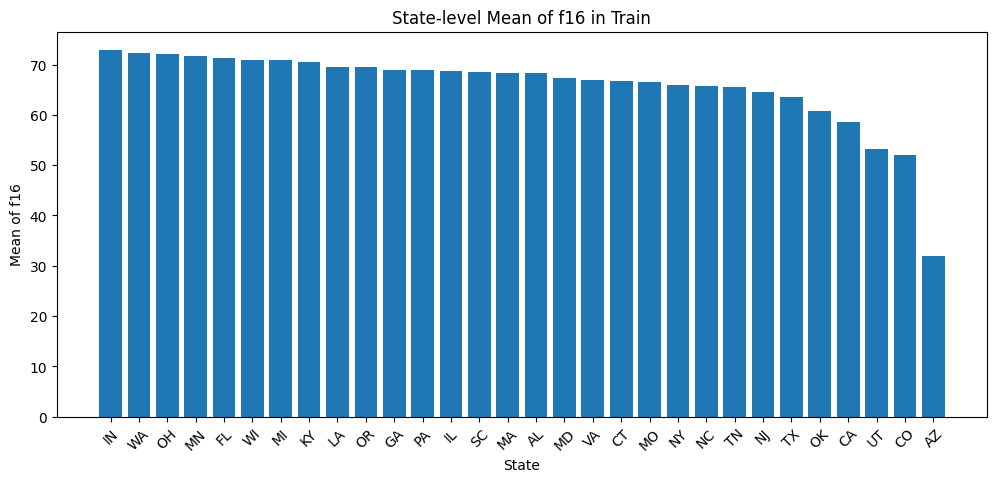

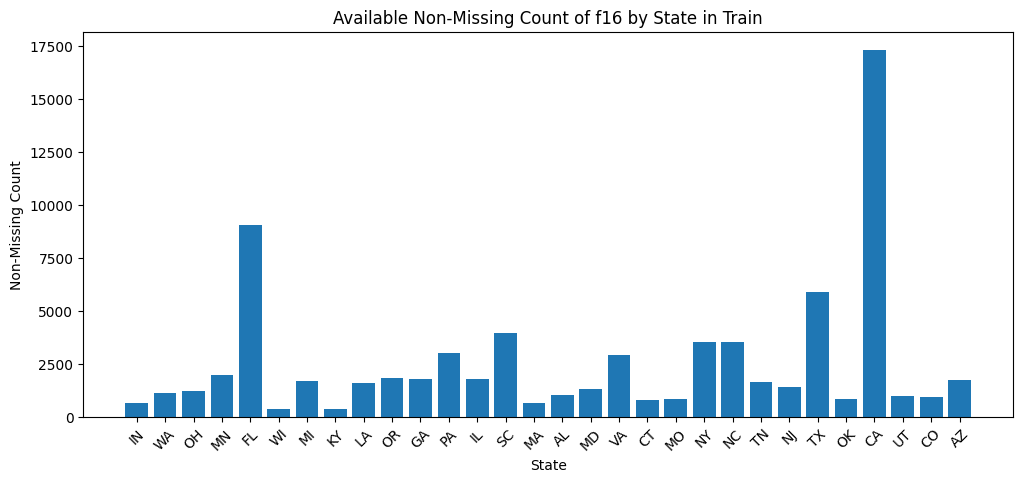

Global mode for f16: 93.0

State effect table for f16:


,state_non_missing_count,state_mean,state_effect_weight,global_mode_weight,impute_value
f11,,,,,
CA,17305,58.566426,0.994255,0.005745,58.764263
FL,9054,71.323062,0.989076,0.010924,71.559865
TX,5897,63.496354,0.983325,0.016675,63.988327
SC,3947,68.581454,0.975290,0.024710,69.184828
NY,3538,65.958451,0.972512,0.027488,66.701759
NC,3507,65.721129,0.972276,0.027724,66.477405
PA,3022,68.940437,0.967969,0.032031,69.711083
VA,2922,66.966119,0.966909,0.033091,67.827598
MN,1962,71.796126,0.951503,0.048497,72.824442


f16 missing count in train after fill: 0
f16 missing count in test after fill: 0


In [181]:
# ============================================================
# 6. f16: مثل f19
# مقدار جایگزین ترکیبی از global mode و میانگین ایالت است.
# ============================================================

col = "f16"

print("\n" + "=" * 80)
print(f"Analysis for {col}")

print(f"{col} missing count in train before fill:", train_processed[col].isna().sum())
print(f"{col} missing percent in train before fill:", train_processed[col].isna().mean() * 100)

display(train_processed[col].describe())

f16_state_raw_stats = plot_state_mean_distribution(
    train_processed,
    col=col,
    state_col="f11",
    top_n=30
)

f16_global_mode, f16_state_stats = fit_state_shrinkage_values(
    train_processed,
    col=col,
    state_col="f11",
    smoothing=100
)

print(f"Global mode for {col}:", f16_global_mode)

print(f"\nState effect table for {col}:")
display(
    f16_state_stats
    .sort_values("state_effect_weight", ascending=False)
)

train_processed = apply_state_shrinkage_imputation(
    train_processed,
    col=col,
    state_stats=f16_state_stats,
    global_mode=f16_global_mode,
    state_col="f11"
)

test_processed = apply_state_shrinkage_imputation(
    test_processed,
    col=col,
    state_stats=f16_state_stats,
    global_mode=f16_global_mode,
    state_col="f11"
)

print(f"{col} missing count in train after fill:", train_processed[col].isna().sum())
print(f"{col} missing count in test after fill:", test_processed[col].isna().sum())




Analysis for f17
f17 missing count in train before fill: 1433
f17 missing percent in train before fill: 1.7912500000000002


count    78567.000000
mean        29.542046
std          1.004706
min          9.900000
25%         29.370000
50%         29.860000
75%         30.030000
max         38.440000
Name: f17, dtype: float64

,count,mean
f11,,
FL,9124,30.014992
DC,190,30.013211
LA,1591,30.004525
DE,152,29.974013
NJ,1395,29.972717
ME,27,29.940741
MA,643,29.928351
MD,1335,29.928187
MS,148,29.900203


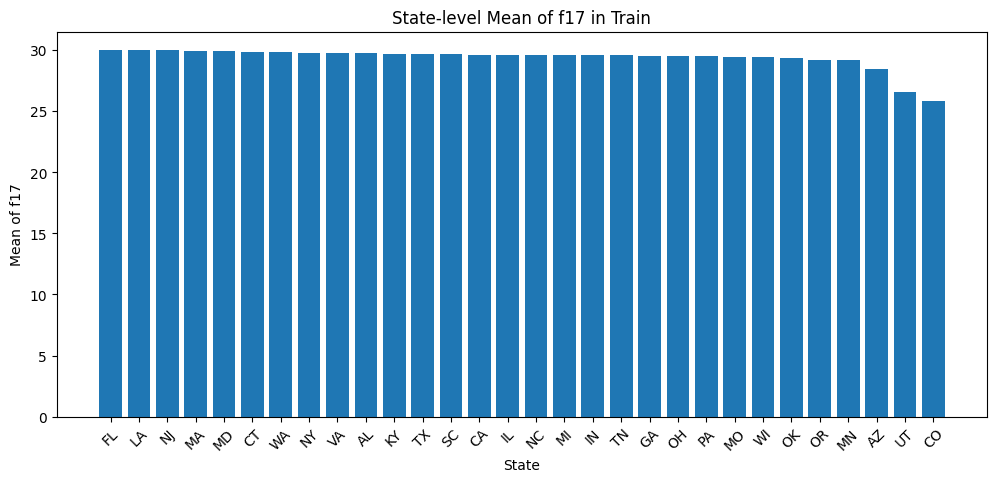

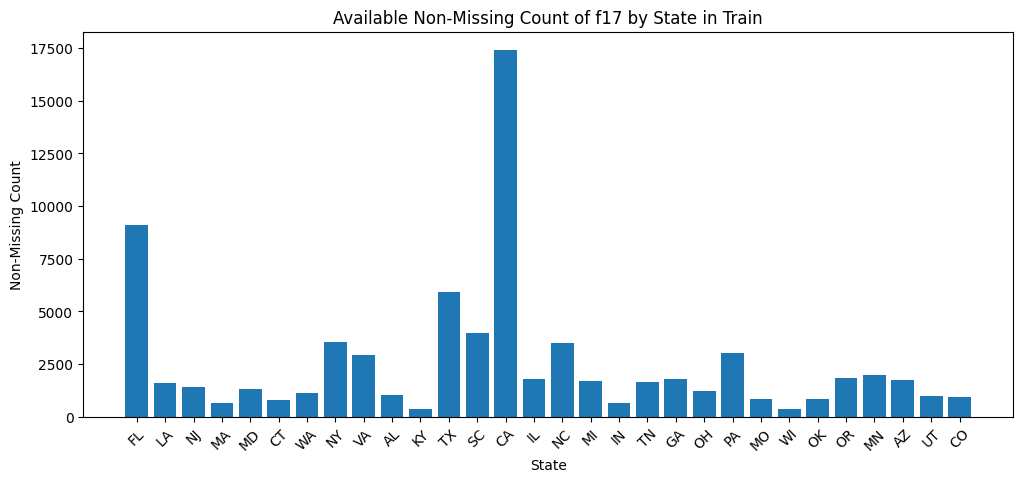

Global mode for f17: 29.96

State effect table for f17:


,state_non_missing_count,state_mean,state_effect_weight,global_mode_weight,impute_value
f11,,,,,
CA,17415,29.633627,0.994291,0.005709,29.635490
FL,9124,30.014992,0.989159,0.010841,30.014396
TX,5914,29.688563,0.983372,0.016628,29.693076
SC,3961,29.678505,0.975376,0.024624,29.685437
NY,3534,29.808475,0.972482,0.027518,29.812644
NC,3508,29.613612,0.972284,0.027716,29.623212
PA,3033,29.502826,0.968082,0.031918,29.517418
VA,2937,29.735560,0.967073,0.032927,29.742950
MN,1969,29.163469,0.951667,0.048333,29.201967


f17 missing count in train after fill: 0
f17 missing count in test after fill: 0


In [182]:
# ============================================================
# 7. f17: مثل f19
# مقدار جایگزین ترکیبی از global mode و میانگین ایالت است.
# ============================================================

col = "f17"

print("\n" + "=" * 80)
print(f"Analysis for {col}")

print(f"{col} missing count in train before fill:", train_processed[col].isna().sum())
print(f"{col} missing percent in train before fill:", train_processed[col].isna().mean() * 100)

display(train_processed[col].describe())

f17_state_raw_stats = plot_state_mean_distribution(
    train_processed,
    col=col,
    state_col="f11",
    top_n=30
)

f17_global_mode, f17_state_stats = fit_state_shrinkage_values(
    train_processed,
    col=col,
    state_col="f11",
    smoothing=100
)

print(f"Global mode for {col}:", f17_global_mode)

print(f"\nState effect table for {col}:")
display(
    f17_state_stats
    .sort_values("state_effect_weight", ascending=False)
)

train_processed = apply_state_shrinkage_imputation(
    train_processed,
    col=col,
    state_stats=f17_state_stats,
    global_mode=f17_global_mode,
    state_col="f11"
)

test_processed = apply_state_shrinkage_imputation(
    test_processed,
    col=col,
    state_stats=f17_state_stats,
    global_mode=f17_global_mode,
    state_col="f11"
)

print(f"{col} missing count in train after fill:", train_processed[col].isna().sum())
print(f"{col} missing count in test after fill:", test_processed[col].isna().sum())



In [183]:
# ============================================================
# 8. f18: یکسان‌سازی جهت باد
#
# مثال:
# N, North, north, NORTH  ---> N
# VAR, Variable, variable ---> VARIABLE
#
# بعد از یکسان‌سازی، missing ها با Unknown پر می‌شوند.
# ============================================================

def normalize_wind_direction(value):
    """
    یکسان‌سازی مقدارهای categorical مربوط به جهت باد.
    """
    if pd.isna(value):
        return "Unknown"
    
    value = str(value).strip().upper()
    
    mapping = {
        "N": "N",
        "NORTH": "N",
        
        "S": "S",
        "SOUTH": "S",
        
        "E": "E",
        "EAST": "E",
        
        "W": "W",
        "WEST": "W",
        
        "NE": "NE",
        "NORTH EAST": "NE",
        "NORTHEAST": "NE",
        
        "NW": "NW",
        "NORTH WEST": "NW",
        "NORTHWEST": "NW",
        
        "SE": "SE",
        "SOUTH EAST": "SE",
        "SOUTHEAST": "SE",
        
        "SW": "SW",
        "SOUTH WEST": "SW",
        "SOUTHWEST": "SW",
        
        "ENE": "ENE",
        "EAST NORTHEAST": "ENE",
        
        "ESE": "ESE",
        "EAST SOUTHEAST": "ESE",
        
        "NNE": "NNE",
        "NORTH NORTHEAST": "NNE",
        
        "NNW": "NNW",
        "NORTH NORTHWEST": "NNW",
        
        "SSE": "SSE",
        "SOUTH SOUTHEAST": "SSE",
        
        "SSW": "SSW",
        "SOUTH SOUTHWEST": "SSW",
        
        "WSW": "WSW",
        "WEST SOUTHWEST": "WSW",
        
        "WNW": "WNW",
        "WEST NORTHWEST": "WNW",
        
        "VAR": "VARIABLE",
        "VARIABLE": "VARIABLE",
        "VRB": "VARIABLE",
        
        "CALM": "CALM"
    }
    
    return mapping.get(value, value)


print("\n" + "=" * 80)
print("f18 before normalization:")
display(train_processed["f18"].value_counts(dropna=False).head(30))

train_processed["f18"] = train_processed["f18"].apply(normalize_wind_direction)
test_processed["f18"] = test_processed["f18"].apply(normalize_wind_direction)

print("f18 after normalization:")
display(train_processed["f18"].value_counts(dropna=False).head(30))

print("f18 missing count in train after normalization:", train_processed["f18"].isna().sum())
print("f18 missing count in test after normalization:", test_processed["f18"].isna().sum())



f18 before normalization:


f18
CALM        9961
S           4249
SSW         4032
WNW         3952
Calm        3939
W           3908
SW          3794
NW          3708
WSW         3660
SSE         3562
NNW         3542
N           3194
SE          2978
E           2893
ESE         2848
NE          2751
NNE         2663
ENE         2654
VAR         2523
NaN         1796
South       1785
West        1740
North       1594
Variable    1222
East        1052
Name: count, dtype: int64

f18 after normalization:


f18
CALM        13900
S            6034
W            5648
N            4788
SSW          4032
WNW          3952
E            3945
SW           3794
VARIABLE     3745
NW           3708
WSW          3660
SSE          3562
NNW          3542
SE           2978
ESE          2848
NE           2751
NNE          2663
ENE          2654
Unknown      1796
Name: count, dtype: int64

f18 missing count in train after normalization: 0
f18 missing count in test after normalization: 0


f18 value counts in train:


f18
CALM        13900
S            6034
W            5648
N            4788
SSW          4032
WNW          3952
E            3945
SW           3794
VARIABLE     3745
NW           3708
WSW          3660
SSE          3562
NNW          3542
SE           2978
ESE          2848
NE           2751
NNE          2663
ENE          2654
Unknown      1796
Name: count, dtype: int64

Missing f18_sin before imputation in train: 1796
Missing f18_cos before imputation in train: 1796
Missing f18_sin before imputation in test: 480
Missing f18_cos before imputation in test: 480

State-level analysis for f18_sin:


,count,mean
f11,,
FL,9067,0.215850
TX,5882,0.136673
LA,1576,0.128551
OK,840,0.056519
MS,147,0.036783
AR,209,0.022688
VT,15,0.005075
CO,941,-0.011173
AL,1008,-0.015327


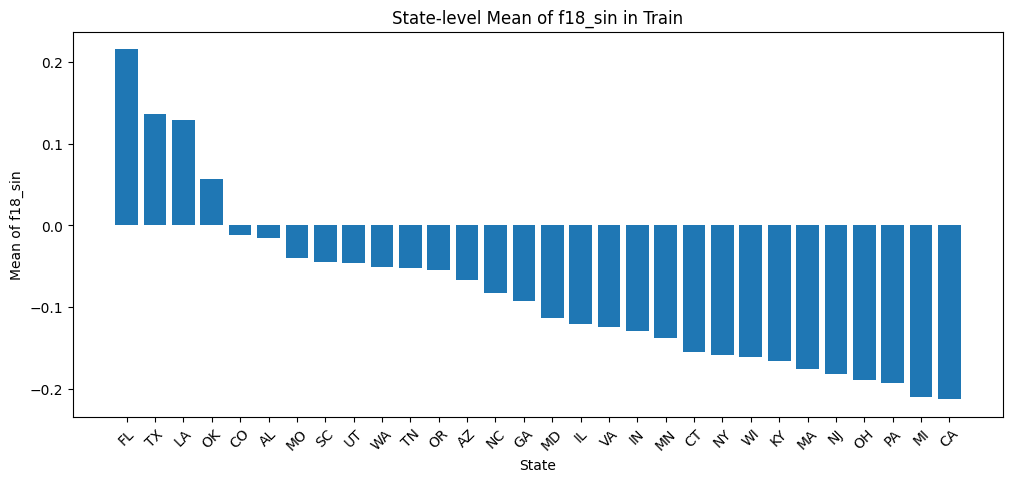

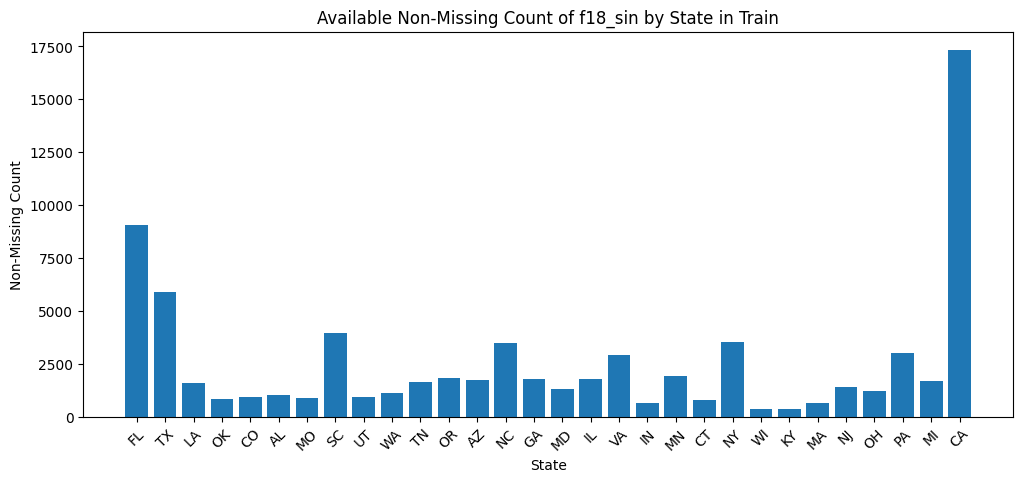

Global mode for f18_sin: 0.0

State effect table for f18_sin:


,state_non_missing_count,state_mean,state_effect_weight,global_mode_weight,impute_value
f11,,,,,
CA,17327,-0.212692,0.994262,0.005738,-0.211472
FL,9067,0.215850,0.989091,0.010909,0.213495
TX,5882,0.136673,0.983283,0.016717,0.134388
SC,3941,-0.045021,0.975254,0.024746,-0.043907
NY,3521,-0.158919,0.972383,0.027617,-0.154530
NC,3503,-0.082449,0.972245,0.027755,-0.080161
PA,3027,-0.193377,0.968020,0.031980,-0.187193
VA,2934,-0.124073,0.967040,0.032960,-0.119984
MN,1937,-0.137385,0.950908,0.049092,-0.130640



State-level analysis for f18_cos:


,count,mean
f11,,
SD,3,0.543662
ND,28,0.405270
VT,15,0.215363
IA,263,0.116886
KS,208,0.092114
WY,27,0.091961
NJ,1385,0.087133
MD,1286,0.072239
MA,643,0.071805


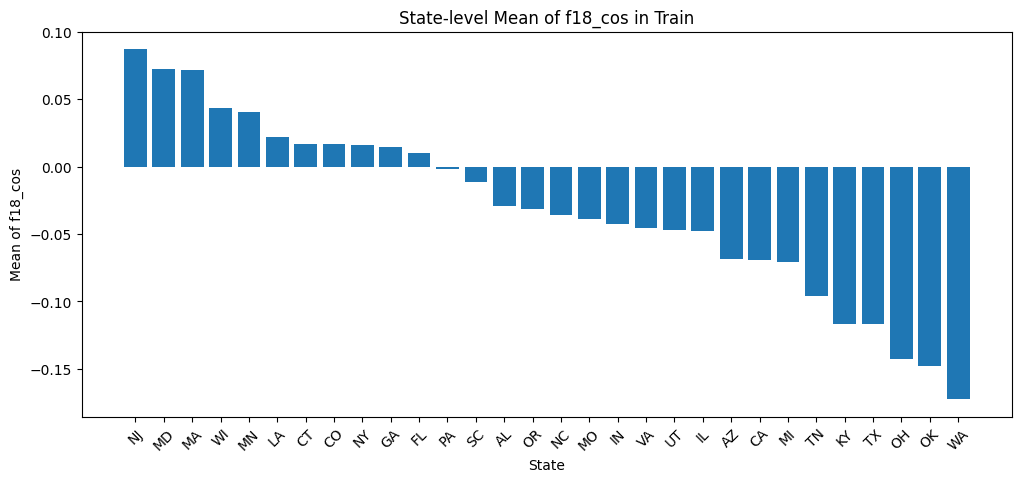

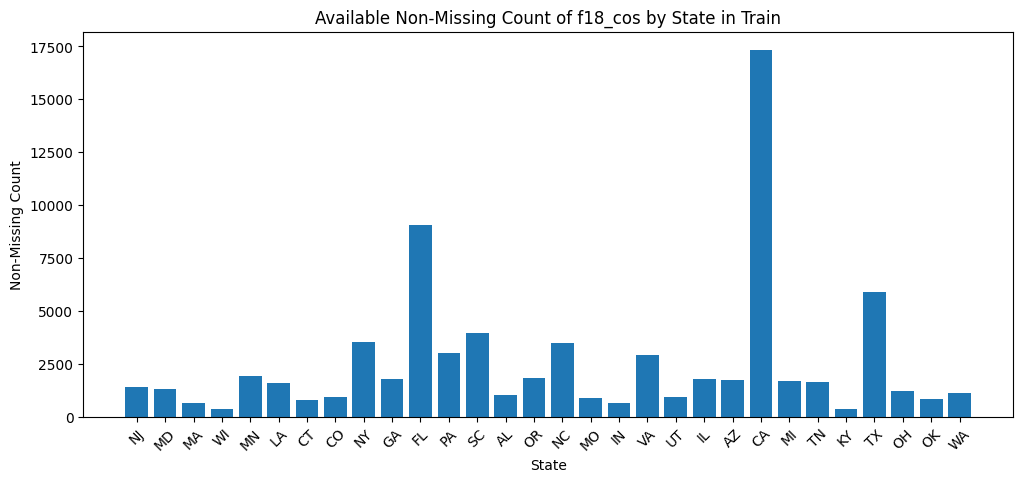

Global mode for f18_cos: 0.0

State effect table for f18_cos:


,state_non_missing_count,state_mean,state_effect_weight,global_mode_weight,impute_value
f11,,,,,
CA,17327,-0.069626,0.994262,0.005738,-0.069227
FL,9067,0.010191,0.989091,0.010909,0.010079
TX,5882,-0.116914,0.983283,0.016717,-0.114960
SC,3941,-0.011078,0.975254,0.024746,-0.010804
NY,3521,0.015746,0.972383,0.027617,0.015311
NC,3503,-0.035733,0.972245,0.027755,-0.034741
PA,3027,-0.001407,0.968020,0.031980,-0.001362
VA,2934,-0.045184,0.967040,0.032960,-0.043694
MN,1937,0.040837,0.950908,0.049092,0.038832


Missing f18_sin after imputation in train: 0
Missing f18_cos after imputation in train: 0
Missing f18_sin after imputation in test: 0
Missing f18_cos after imputation in test: 0

Final f18 engineered features preview:


,f18,f18_degree,f18_sin,f18_cos,f18_calm,f18_variable
0,ENE,67.5,9.238795e-01,3.826834e-01,0,0
1,CALM,NaN,0.000000e+00,0.000000e+00,1,0
2,SSE,157.5,3.826834e-01,-9.238795e-01,0,0
3,SE,135.0,7.071068e-01,-7.071068e-01,0,0
4,S,180.0,1.224647e-16,-1.000000e+00,0,0
5,VARIABLE,NaN,0.000000e+00,0.000000e+00,0,1
6,WNW,292.5,-9.238795e-01,3.826834e-01,0,0
7,S,180.0,1.224647e-16,-1.000000e+00,0,0
8,CALM,NaN,0.000000e+00,0.000000e+00,1,0
9,NNW,337.5,-3.826834e-01,9.238795e-01,0,0


In [184]:
# ============================================================
# f18 Feature Engineering After Normalization
#
# هدف:
# f18 جهت باد است.
# چون جهت باد circular است، تبدیل مستقیم آن به عدد معمولی مناسب نیست.
# مثلا زاویه 0 و 337.5 از نظر واقعی نزدیک‌اند،
# اما اگر فقط عدد خام استفاده کنیم فاصله آن‌ها زیاد دیده می‌شود.
#
# بنابراین:
# 1. جهت‌های اصلی باد را به درجه تبدیل می‌کنیم.
# 2. از درجه‌ها sin و cos می‌سازیم.
# 3. برای CALM و VARIABLE دو ستون جدا می‌سازیم.
# 4. برای UNKNOWN، ابتدا sin/cos را NaN می‌گذاریم،
#    سپس مثل روش f19 با ترکیب global mode و میانگین ایالت پر می‌کنیم.
# ============================================================


# ============================================================
# 1. تعریف mapping جهت باد به زاویه
# ============================================================

wind_dir_to_degree = {
    "n": 0,
    "nne": 22.5,
    "ne": 45,
    "ene": 67.5,
    "e": 90,
    "ese": 112.5,
    "se": 135,
    "sse": 157.5,
    "s": 180,
    "ssw": 202.5,
    "sw": 225,
    "wsw": 247.5,
    "w": 270,
    "wnw": 292.5,
    "nw": 315,
    "nnw": 337.5
}


# ============================================================
# 2. ساخت تابع برای تبدیل f18 به featureهای عددی
# ============================================================

def create_wind_direction_features(df, wind_col="f18"):
    """
    این تابع از ستون f18 چند feature جدید می‌سازد:
    
    f18_calm:
        اگر جهت باد CALM باشد برابر 1، در غیر این صورت 0.
    
    f18_variable:
        اگر جهت باد VARIABLE باشد برابر 1، در غیر این صورت 0.
    
    f18_degree:
        زاویه جهت باد.
        برای UNKNOWN / CALM / VARIABLE مقدار NaN می‌گیرد.
    
    f18_sin و f18_cos:
        نمایش circular جهت باد.
        برای CALM و VARIABLE برابر 0 قرار داده می‌شود.
        برای UNKNOWN موقتاً NaN می‌ماند تا بعداً با روش shrinkage پر شود.
    """
    
    result = df.copy()
    
    # چون بعد از normalization مقدارها معمولا uppercase هستند،
    # برای mapping آن‌ها را lowercase می‌کنیم.
    wind_clean = (
        result[wind_col]
        .fillna("Unknown")
        .astype(str)
        .str.strip()
        .str.lower()
    )
    
    # ستون‌های indicator برای CALM و VARIABLE
    result["f18_calm"] = (wind_clean == "calm").astype(int)
    result["f18_variable"] = (wind_clean == "variable").astype(int)
    
    # تبدیل جهت‌های واقعی باد به درجه
    # UNKNOWN / CALM / VARIABLE در این مرحله NaN می‌شوند.
    result["f18_degree"] = wind_clean.map(wind_dir_to_degree)
    
    # تبدیل درجه به رادیان برای محاسبه sin/cos
    wind_radian = np.deg2rad(result["f18_degree"])
    
    result["f18_sin"] = np.sin(wind_radian)
    result["f18_cos"] = np.cos(wind_radian)
    
    # برای CALM و VARIABLE جهت مشخصی نداریم،
    # اما خود این حالت‌ها را با ستون‌های f18_calm و f18_variable نگه داشته‌ایم.
    # بنابراین sin/cos آن‌ها را صفر می‌گذاریم.
    calm_or_variable_mask = (result["f18_calm"] == 1) | (result["f18_variable"] == 1)
    
    result.loc[calm_or_variable_mask, "f18_sin"] = 0
    result.loc[calm_or_variable_mask, "f18_cos"] = 0
    
    return result


# ============================================================
# 3. ساخت featureهای جدید برای train و test
# ============================================================

train_processed = create_wind_direction_features(train_processed, wind_col="f18")
test_processed = create_wind_direction_features(test_processed, wind_col="f18")


# ============================================================
# 4. بررسی تعداد مقدارهای UNKNOWN که باعث NaN در sin/cos شده‌اند
# ============================================================

print("f18 value counts in train:")
display(train_processed["f18"].value_counts(dropna=False))

print("Missing f18_sin before imputation in train:", train_processed["f18_sin"].isna().sum())
print("Missing f18_cos before imputation in train:", train_processed["f18_cos"].isna().sum())

print("Missing f18_sin before imputation in test:", test_processed["f18_sin"].isna().sum())
print("Missing f18_cos before imputation in test:", test_processed["f18_cos"].isna().sum())


# ============================================================
# 5. نمایش تفاوت میانگین f18_sin در ایالت‌های مختلف
# ============================================================

print("\nState-level analysis for f18_sin:")
f18_sin_state_raw_stats = plot_state_mean_distribution(
    train_processed,
    col="f18_sin",
    state_col="f11",
    top_n=30
)


# ============================================================
# 6. پر کردن UNKNOWNهای f18_sin با روش shrinkage مثل f19
# ============================================================

f18_sin_global_mode, f18_sin_state_stats = fit_state_shrinkage_values(
    train_processed,
    col="f18_sin",
    state_col="f11",
    smoothing=100
)

print("Global mode for f18_sin:", f18_sin_global_mode)

print("\nState effect table for f18_sin:")
display(
    f18_sin_state_stats
    .sort_values("state_effect_weight", ascending=False)
)

train_processed = apply_state_shrinkage_imputation(
    train_processed,
    col="f18_sin",
    state_stats=f18_sin_state_stats,
    global_mode=f18_sin_global_mode,
    state_col="f11"
)

test_processed = apply_state_shrinkage_imputation(
    test_processed,
    col="f18_sin",
    state_stats=f18_sin_state_stats,
    global_mode=f18_sin_global_mode,
    state_col="f11"
)


# ============================================================
# 7. نمایش تفاوت میانگین f18_cos در ایالت‌های مختلف
# ============================================================

print("\nState-level analysis for f18_cos:")
f18_cos_state_raw_stats = plot_state_mean_distribution(
    train_processed,
    col="f18_cos",
    state_col="f11",
    top_n=30
)


# ============================================================
# 8. پر کردن UNKNOWNهای f18_cos با روش shrinkage مثل f19
# ============================================================

f18_cos_global_mode, f18_cos_state_stats = fit_state_shrinkage_values(
    train_processed,
    col="f18_cos",
    state_col="f11",
    smoothing=100
)

print("Global mode for f18_cos:", f18_cos_global_mode)

print("\nState effect table for f18_cos:")
display(
    f18_cos_state_stats
    .sort_values("state_effect_weight", ascending=False)
)

train_processed = apply_state_shrinkage_imputation(
    train_processed,
    col="f18_cos",
    state_stats=f18_cos_state_stats,
    global_mode=f18_cos_global_mode,
    state_col="f11"
)

test_processed = apply_state_shrinkage_imputation(
    test_processed,
    col="f18_cos",
    state_stats=f18_cos_state_stats,
    global_mode=f18_cos_global_mode,
    state_col="f11"
)


# ============================================================
# 9. بررسی نهایی
# ============================================================

print("Missing f18_sin after imputation in train:", train_processed["f18_sin"].isna().sum())
print("Missing f18_cos after imputation in train:", train_processed["f18_cos"].isna().sum())

print("Missing f18_sin after imputation in test:", test_processed["f18_sin"].isna().sum())
print("Missing f18_cos after imputation in test:", test_processed["f18_cos"].isna().sum())

print("\nFinal f18 engineered features preview:")
display(
    train_processed[
        ["f18", "f18_degree", "f18_sin", "f18_cos", "f18_calm", "f18_variable"]
    ].head(20)
)


f15 missing count in train before fill: 1211
f15 missing percent in train before fill: 1.51375

Signed time difference between f15 and f2 in minutes:


count    71195.000000
mean         0.717326
std         40.902833
min      -1200.500000
25%        -11.250000
50%          0.000000
75%         11.500000
max       1306.950000
dtype: float64


Mean signed time difference between f15 and f2 in minutes: 0.7173258889903316


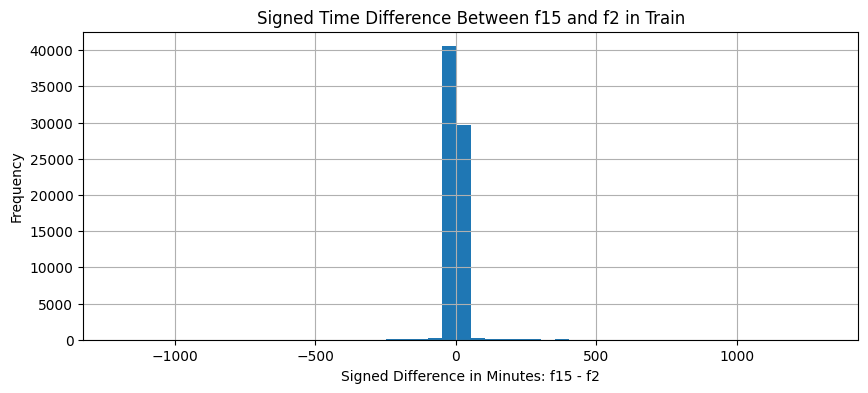

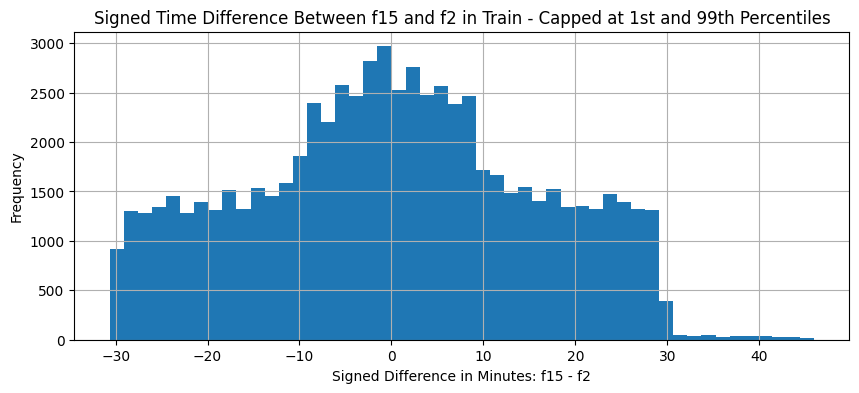

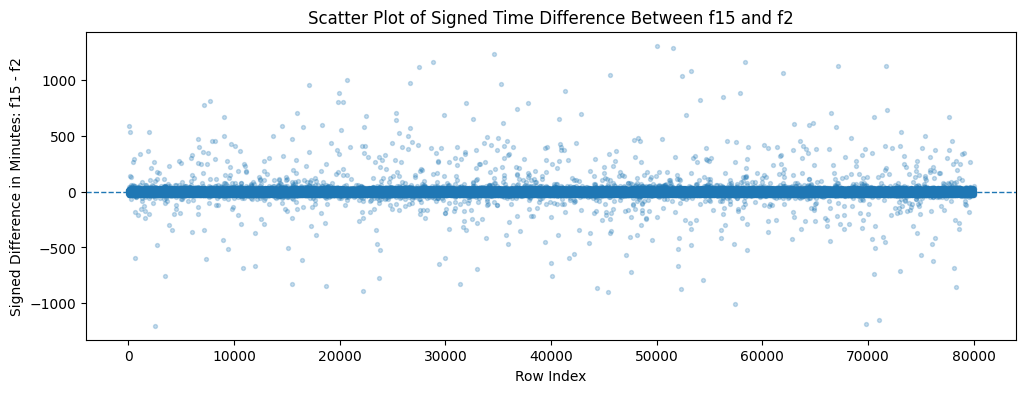

f15 missing count in train after fill: 135
f15 missing count in test after fill: 40


In [185]:
# ============================================================
# 9. f15: بررسی اختلاف زمانی واقعی با f2 و سپس پر کردن f15
#
# f2 احتمالاً زمان شروع حادثه است.
# f15 احتمالاً timestamp مربوط به آب‌وهواست.
#
# در این نسخه، اختلاف زمانی به صورت signed محاسبه می‌شود:
# time_diff = f15 - f2
#
# یعنی:
# اگر f15 بعد از f2 باشد  → اختلاف مثبت است.
# اگر f15 قبل از f2 باشد → اختلاف منفی است.
#
# سپس missing های f15 با مقدار زیر پر می‌شوند:
# f15 = f2 + mean(time_diff)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# تبدیل f2 و f15 به datetime
train_processed["f2"] = pd.to_datetime(train_processed["f2"], errors="coerce")
test_processed["f2"] = pd.to_datetime(test_processed["f2"], errors="coerce")

train_processed["f15"] = pd.to_datetime(train_processed["f15"], errors="coerce")
test_processed["f15"] = pd.to_datetime(test_processed["f15"], errors="coerce")


# محاسبه اختلاف زمانی واقعی بین f15 و f2 بر حسب دقیقه
# اینجا abs() نداریم
train_time_diff_minutes = (
    train_processed["f15"] - train_processed["f2"]
).dt.total_seconds() / 60


print("\n" + "=" * 80)
print("f15 missing count in train before fill:", train_processed["f15"].isna().sum())
print("f15 missing percent in train before fill:", train_processed["f15"].isna().mean() * 100)

print("\nSigned time difference between f15 and f2 in minutes:")
display(train_time_diff_minutes.describe())


# محاسبه میانگین اختلاف واقعی
mean_time_diff_minutes = train_time_diff_minutes.dropna().mean()

print("\nMean signed time difference between f15 and f2 in minutes:", mean_time_diff_minutes)


# نمودار histogram اختلاف زمانی واقعی
# این نمودار می‌تواند مقدارهای منفی و مثبت را نشان دهد
plt.figure(figsize=(10, 4))
train_time_diff_minutes.dropna().hist(bins=50)
plt.title("Signed Time Difference Between f15 and f2 in Train")
plt.xlabel("Signed Difference in Minutes: f15 - f2")
plt.ylabel("Frequency")
plt.show()


# برای اینکه بخش اصلی توزیع بهتر دیده شود،
# به جای صدک 99 قدرمطلق، از بازه صدک 1 تا 99 خود اختلاف واقعی استفاده می‌کنیم
q01 = train_time_diff_minutes.quantile(0.01)
q99 = train_time_diff_minutes.quantile(0.99)

plt.figure(figsize=(10, 4))
train_time_diff_minutes[
    (train_time_diff_minutes >= q01) &
    (train_time_diff_minutes <= q99)
].dropna().hist(bins=50)
plt.title("Signed Time Difference Between f15 and f2 in Train - Capped at 1st and 99th Percentiles")
plt.xlabel("Signed Difference in Minutes: f15 - f2")
plt.ylabel("Frequency")
plt.show()


# نمودار پراکندگی اختلاف زمانی واقعی
plt.figure(figsize=(12, 4))
plt.scatter(
    train_processed.index,
    train_time_diff_minutes,
    alpha=0.25,
    s=8
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Scatter Plot of Signed Time Difference Between f15 and f2")
plt.xlabel("Row Index")
plt.ylabel("Signed Difference in Minutes: f15 - f2")
plt.show()


# پر کردن missing های f15 با f2 همان ردیف
train_processed["f15"] = train_processed["f15"].fillna(train_processed["f2"])
test_processed["f15"] = test_processed["f15"].fillna(test_processed["f2"])

print("f15 missing count in train after fill:", train_processed["f15"].isna().sum())
print("f15 missing count in test after fill:", test_processed["f15"].isna().sum())



In [186]:
# ============================================================
# 10. f14 و f12: پر کردن با Unknown
#
# دلیل:
# f14 احتمالاً Airport Code است.
# f12 احتمالاً Zipcode است.
# این‌ها مقدارهای مکانی واقعی هستند.
# استفاده از mode ممکن است مکان جعلی بسازد.
# پس Unknown بهتر است.
# ============================================================

for col in ["f14", "f12"]:
    print("\n" + "=" * 80)
    print(f"{col} missing count in train before fill:", train_processed[col].isna().sum())
    print(f"{col} missing count in test before fill:", test_processed[col].isna().sum())
    
    train_processed[col] = train_processed[col].fillna("Unknown")
    test_processed[col] = test_processed[col].fillna("Unknown")
    
    print(f"{col} missing count in train after fill:", train_processed[col].isna().sum())
    print(f"{col} missing count in test after fill:", test_processed[col].isna().sum())


f14 missing count in train before fill: 240
f14 missing count in test before fill: 64
f14 missing count in train after fill: 0
f14 missing count in test after fill: 0

f12 missing count in train before fill: 28
f12 missing count in test before fill: 2
f12 missing count in train after fill: 0
f12 missing count in test after fill: 0


In [187]:
# ============================================================
# 11. f8: پر کردن Street با Unknown
#
# دلیل:
# اسم خیابان مقدار واقعی مکانی است.
# جایگزینی با پرتکرارترین خیابان باعث ساختن مکان جعلی می‌شود.
# ============================================================

print("\n" + "=" * 80)
print("f8 missing count in train before fill:", train_processed["f8"].isna().sum())
print("f8 missing count in test before fill:", test_processed["f8"].isna().sum())

train_processed["f8"] = train_processed["f8"].fillna("Unknown")
test_processed["f8"] = test_processed["f8"].fillna("Unknown")

print("f8 missing count in train after fill:", train_processed["f8"].isna().sum())
print("f8 missing count in test after fill:", test_processed["f8"].isna().sum())



f8 missing count in train before fill: 117
f8 missing count in test before fill: 23
f8 missing count in train after fill: 0
f8 missing count in test after fill: 0



Analysis for f32
f32 missing count in train before fill: 217
f32 missing percent in train before fill: 0.27125


,count,percent
f32,,
Day,55327,69.15875
Night,24456,30.57000
NaN,217,0.27125


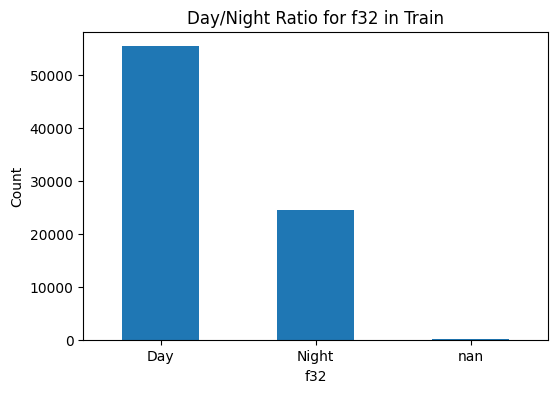

Mode of f32 from train: Day
f32 missing count in train after fill: 0
f32 missing count in test after fill: 0

Analysis for f33
f33 missing count in train before fill: 217
f33 missing percent in train before fill: 0.27125


,count,percent
f33,,
Day,63004,78.75500
Night,16779,20.97375
NaN,217,0.27125


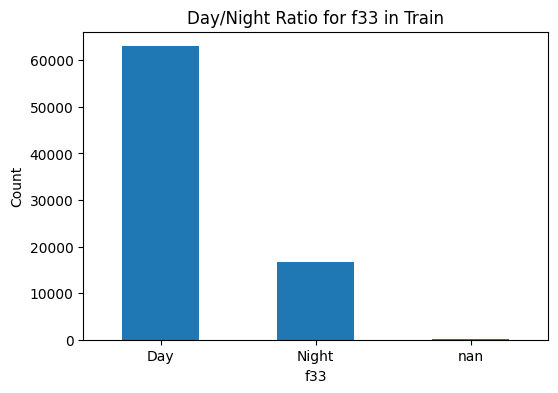

Mode of f33 from train: Day
f33 missing count in train after fill: 0
f33 missing count in test after fill: 0

Analysis for f34
f34 missing count in train before fill: 217
f34 missing percent in train before fill: 0.27125


,count,percent
f34,,
Day,66079,82.59875
Night,13704,17.13000
NaN,217,0.27125


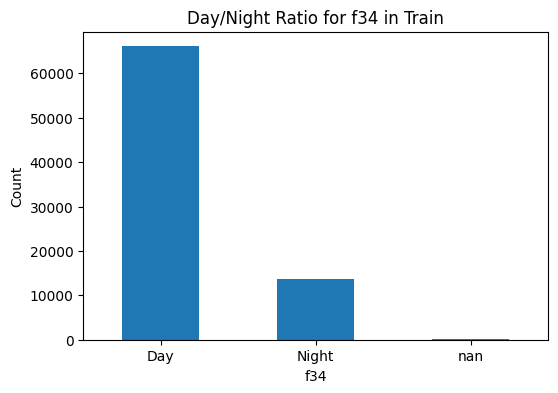

Mode of f34 from train: Day
f34 missing count in train after fill: 0
f34 missing count in test after fill: 0


In [188]:
# ============================================================
# 12. f32, f33, f34: نشان دادن نسبت Day/Night و پر کردن با mode
#
# دلیل:
# این ستون‌ها categorical با مقدارهای Day/Night هستند.
# مقدار missing آن‌ها کم است.
# پس mode از train برای پر کردن مناسب است.
# ============================================================

day_night_cols = ["f32", "f33", "f34"]

day_night_modes = {}

for col in day_night_cols:
    print("\n" + "=" * 80)
    print(f"Analysis for {col}")
    
    print(f"{col} missing count in train before fill:", train_processed[col].isna().sum())
    print(f"{col} missing percent in train before fill:", train_processed[col].isna().mean() * 100)
    
    ratio_table = (
        train_processed[col]
        .value_counts(dropna=False)
        .to_frame("count")
    )
    ratio_table["percent"] = ratio_table["count"] / len(train_processed) * 100
    
    display(ratio_table)
    
    plt.figure(figsize=(6, 4))
    train_processed[col].value_counts(dropna=False).plot(kind="bar")
    plt.title(f"Day/Night Ratio for {col} in Train")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.show()
    
    mode_value = train_processed[col].mode(dropna=True).iloc[0]
    day_night_modes[col] = mode_value
    
    print(f"Mode of {col} from train:", mode_value)
    
    train_processed[col] = train_processed[col].fillna(mode_value)
    test_processed[col] = test_processed[col].fillna(mode_value)
    
    print(f"{col} missing count in train after fill:", train_processed[col].isna().sum())
    print(f"{col} missing count in test after fill:", test_processed[col].isna().sum())


In [189]:
train_processed.head()

,f1,f2,f3,f6,f7,f8,f9,f10,f11,f12,...,f31,f32,f33,f34,y,f18_calm,f18_variable,f18_degree,f18_sin,f18_cos
0,Source1,2020-03-25 15:12:29,-73.057920,0.000,At CT-73/Exit 35 - Accident. Hard shoulder blo...,CT-73,Waterbury,New Haven,CT,06708,...,False,Day,Day,Day,2,0,0,67.5,9.238795e-01,0.382683
1,Source2,2019-01-11 21:40:03,-78.745361,0.000,Accident on NC-54 Chapel Hill Rd at I-40.,Chapel Hill Rd,Raleigh,Wake,NC,27607,...,False,Night,Night,Night,2,1,0,NaN,0.000000e+00,0.000000
2,Source1,2022-06-23 20:35:00,-121.576765,0.449,Incident on LONE TREE RD near HOUSE 962 Expect...,Sunnybrook Ln,Oroville,Butte,CA,95965-8112,...,False,Day,Day,Day,2,0,0,157.5,3.826834e-01,-0.923880
3,Source1,2022-09-11 23:46:40,-73.737432,0.019,NYSDOT TMC - Albany: Crash on I-90 westbound a...,I-90 W,Albany,Albany,NY,12204,...,False,Night,Night,Night,2,0,0,135.0,7.071068e-01,-0.707107
4,Source2,2016-10-16 16:06:30,-121.630386,0.010,Accident on US-101 El Camino Real Southbound a...,El Camino Real N,Salinas,Monterey,CA,93907,...,False,Day,Day,Day,2,0,0,180.0,1.224647e-16,-1.000000


In [190]:
# ============================================================
# Noise & Outlier Detection / Removal
# فقط روی train انجام می‌دهیم.
#
# فرض:
# train_processed از مرحله Missing Data Handling ساخته شده است.
#
# نکته:
# test_processed را حذف ردیفی نمی‌کنیم، چون test باید نقش داده unseen را داشته باشد.
# حذف outlier فقط روی train انجام می‌شود.
# ============================================================

outlier_cols = ["f3", "f6", "f16", "f17", "f19"]

# اطمینان از عددی بودن ستون‌ها
for col in outlier_cols:
    train_processed[col] = pd.to_numeric(train_processed[col], errors="coerce")



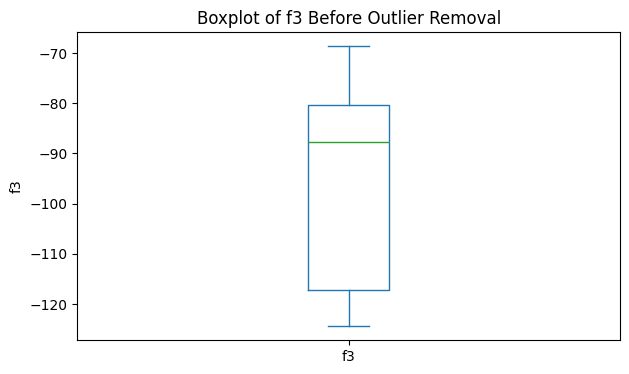

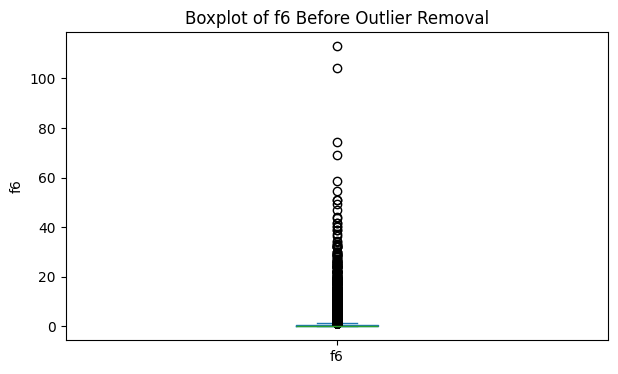

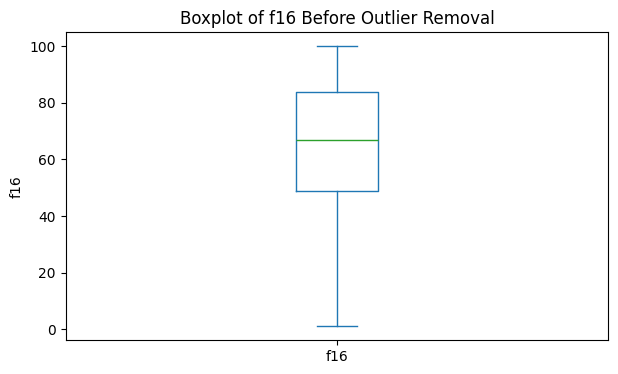

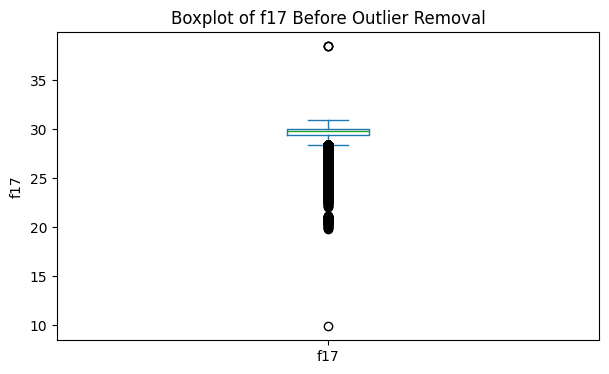

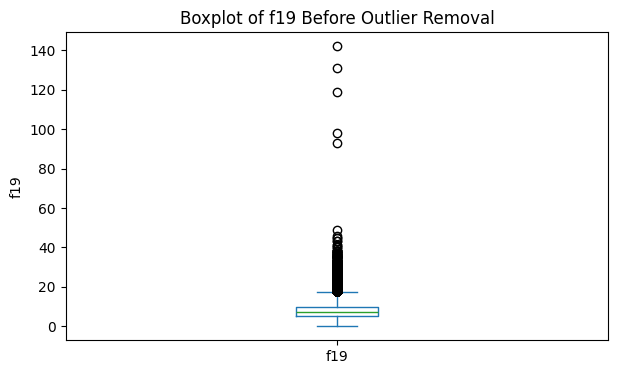

In [191]:
# ============================================================
# 1. رسم Boxplot اولیه برای هر ستون عددی
# ============================================================

for col in outlier_cols:
    plt.figure(figsize=(7, 4))
    train_processed[col].dropna().plot(kind="box")
    plt.title(f"Boxplot of {col} Before Outlier Removal")
    plt.ylabel(col)
    plt.show()

In [192]:
# ============================================================
# 2. بررسی آماری اولیه هر ستون
# ============================================================

outlier_initial_summary = train_processed[outlier_cols].describe().T
outlier_initial_summary["missing_count"] = train_processed[outlier_cols].isna().sum()
outlier_initial_summary["unique_count"] = train_processed[outlier_cols].nunique()

display(outlier_initial_summary)

,count,mean,std,min,25%,50%,75%,max,missing_count,unique_count
f3,80000.0,-94.598202,17.363439,-124.433974,-117.171112,-87.675553,-80.347273,-68.65824,0,73708
f6,80000.0,0.560346,1.775739,0.000000,0.000000,0.030000,0.465000,112.96800,0,5600
f16,80000.0,64.758173,22.650622,1.000000,49.000000,67.000000,84.000000,100.00000,0,143
f17,80000.0,29.540265,1.001247,9.900000,29.380000,29.850000,30.030000,38.44000,0,878
f19,80000.0,7.621980,5.128616,0.000000,5.000000,7.000000,10.000000,142.00000,0,125


In [193]:
def get_iqr_bounds(df, col, multiplier=1.5):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - multiplier * iqr
    upper_bound = q3 + multiplier * iqr
    
    return q1, q3, iqr, lower_bound, upper_bound


# ============================================================
# 5. محاسبه boundهای outlier برای هر ستون
# ============================================================

iqr_rows = []
iqr_bounds = {}

for col in outlier_cols:
    q1, q3, iqr, lower_bound, upper_bound = get_iqr_bounds(
        train_processed,
        col,
        multiplier=1.5
    )
    
    iqr_bounds[col] = {
        "lower_bound": lower_bound,
        "upper_bound": upper_bound
    }
    
    outlier_mask_col = (
        train_processed[col].notna() &
        (
            (train_processed[col] < lower_bound) |
            (train_processed[col] > upper_bound)
        )
    )
    
    lower_outlier_count = (
        train_processed[col].notna() &
        (train_processed[col] < lower_bound)
    ).sum()
    
    upper_outlier_count = (
        train_processed[col].notna() &
        (train_processed[col] > upper_bound)
    ).sum()
    
    iqr_rows.append({
        "feature": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "lower_outlier_count": lower_outlier_count,
        "upper_outlier_count": upper_outlier_count,
        "total_outlier_count": outlier_mask_col.sum(),
        "outlier_percent": outlier_mask_col.mean() * 100
    })

iqr_summary = pd.DataFrame(iqr_rows)

display(iqr_summary)


# ============================================================
# 6. به جای حذف outlierها، مقدارها را به کران پایین و بالا محدود می‌کنیم
# ============================================================

train_processed_clipped = train_processed.copy()
test_processed_clipped = test_processed.copy()

for col in outlier_cols:
    lower_bound = iqr_bounds[col]["lower_bound"]
    upper_bound = iqr_bounds[col]["upper_bound"]
    
    print("=" * 80)
    print(f"Feature: {col}")
    print("Lower bound:", lower_bound)
    print("Upper bound:", upper_bound)
    
    train_lower_count = (
        train_processed_clipped[col].notna() &
        (train_processed_clipped[col] < lower_bound)
    ).sum()
    
    train_upper_count = (
        train_processed_clipped[col].notna() &
        (train_processed_clipped[col] > upper_bound)
    ).sum()
    
    test_lower_count = (
        test_processed_clipped[col].notna() &
        (test_processed_clipped[col] < lower_bound)
    ).sum()
    
    test_upper_count = (
        test_processed_clipped[col].notna() &
        (test_processed_clipped[col] > upper_bound)
    ).sum()
    
    print("Train values below lower bound:", train_lower_count)
    print("Train values above upper bound:", train_upper_count)
    print("Test values below lower bound:", test_lower_count)
    print("Test values above upper bound:", test_upper_count)
    
    # محدود کردن مقدارهای train و test
    # کران‌ها فقط از train محاسبه شده‌اند
    train_processed_clipped[col] = train_processed_clipped[col].clip(
        lower=lower_bound,
        upper=upper_bound
    )
    
    test_processed_clipped[col] = test_processed_clipped[col].clip(
        lower=lower_bound,
        upper=upper_bound
    )


# ============================================================
# 7. بررسی نهایی بعد از clipping
# ============================================================

print("\n" + "=" * 80)
print("Total rows in train before clipping:", len(train_processed))
print("Total rows in train after clipping:", len(train_processed_clipped))

print("\nNo rows were removed. Outlier values were capped instead.")

,feature,Q1,Q3,IQR,lower_bound,upper_bound,lower_outlier_count,upper_outlier_count,total_outlier_count,outlier_percent
0,f3,-117.171112,-80.347273,36.823839,-172.40687,-25.111514,0,0,0,0.00000
1,f6,0.000000,0.465000,0.465000,-0.69750,1.162500,0,9920,9920,12.40000
2,f16,49.000000,84.000000,35.000000,-3.50000,136.500000,0,0,0,0.00000
3,f17,29.380000,30.030000,0.650000,28.40500,31.005000,4717,3,4720,5.90000
4,f19,5.000000,10.000000,5.000000,-2.50000,17.500000,0,3067,3067,3.83375


Feature: f3
Lower bound: -172.4068705
Upper bound: -25.111514499999977
Train values below lower bound: 0
Train values above upper bound: 0
Test values below lower bound: 0
Test values above upper bound: 0
Feature: f6
Lower bound: -0.6975
Upper bound: 1.1625
Train values below lower bound: 0
Train values above upper bound: 9920
Test values below lower bound: 0
Test values above upper bound: 2425
Feature: f16
Lower bound: -3.5
Upper bound: 136.5
Train values below lower bound: 0
Train values above upper bound: 0
Test values below lower bound: 0
Test values above upper bound: 0
Feature: f17
Lower bound: 28.404999999999994
Upper bound: 31.005000000000003
Train values below lower bound: 4717
Train values above upper bound: 3
Test values below lower bound: 1187
Test values above upper bound: 1
Feature: f19
Lower bound: -2.5
Upper bound: 17.5
Train values below lower bound: 0
Train values above upper bound: 3067
Test values below lower bound: 0
Test values above upper bound: 701

Total rows i

,before_count,before_percent,after_count,after_percent
y,,,,
1,702,0.87750,702,0.87750
2,63696,79.62000,63696,79.62000
3,13497,16.87125,13497,16.87125
4,2105,2.63125,2105,2.63125


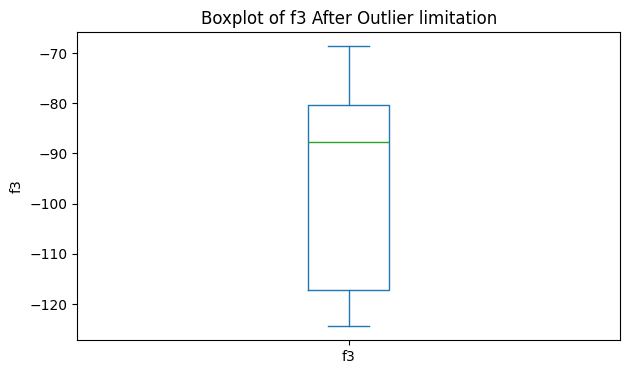

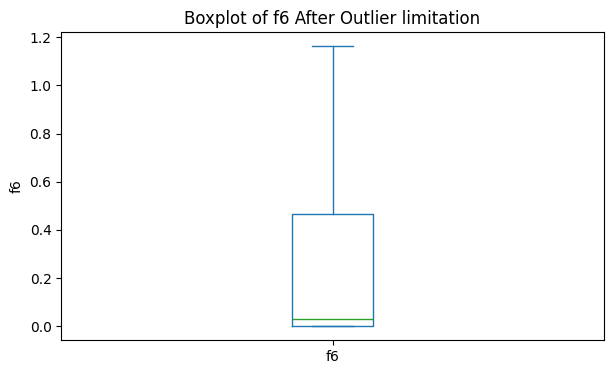

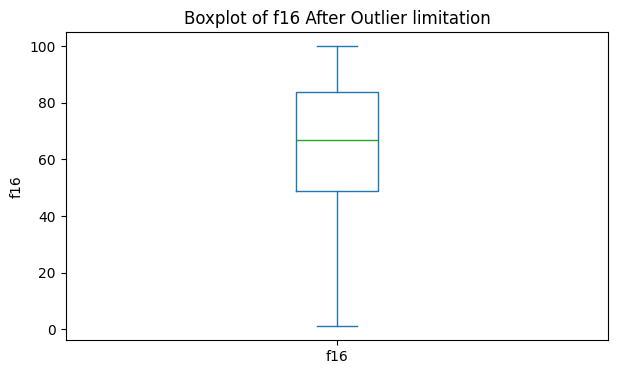

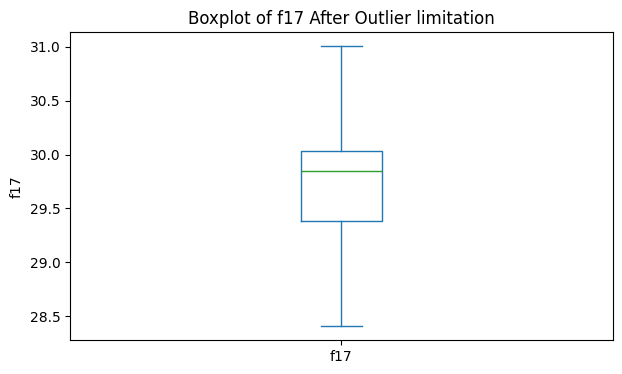

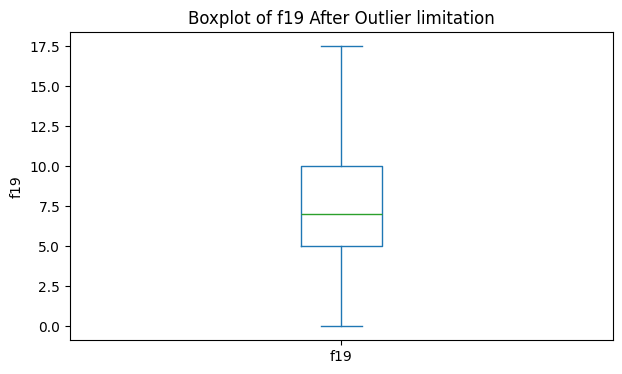

,count,mean,std,min,25%,50%,75%,max,missing_count,unique_count
f3,80000.0,-94.598202,17.363439,-124.433974,-117.171112,-87.675553,-80.347273,-68.65824,0,73708
f6,80000.0,0.287408,0.418047,0.000000,0.000000,0.030000,0.465000,1.16250,0,1276
f16,80000.0,64.758173,22.650622,1.000000,49.000000,67.000000,84.000000,100.00000,0,143
f17,80000.0,29.667680,0.521691,28.405000,29.380000,29.850000,30.030000,31.00500,0,284
f19,80000.0,7.471161,4.649642,0.000000,5.000000,7.000000,10.000000,17.50000,0,79


Final train_processed shape after noise/outlier removal: (80000, 38)


In [194]:
# ============================================================
# 8. مقایسه توزیع کلاس y قبل و بعد از حذف outlier
#
# چون دیتاست نامتوازن است، باید بررسی کنیم حذف outlierها
# باعث حذف شدید یک کلاس خاص نشده باشد.
# ============================================================

target_col = "y"

class_comparison = pd.DataFrame({
    "before_count": train_processed[target_col].value_counts().sort_index(),
    "before_percent": train_processed[target_col].value_counts(normalize=True).sort_index() * 100,
    "after_count": train_processed_clipped[target_col].value_counts().sort_index(),
    "after_percent": train_processed_clipped[target_col].value_counts(normalize=True).sort_index() * 100
})

display(class_comparison)


# ============================================================
# 9. رسم Boxplot بعد از حذف outlierها
# ============================================================

for col in outlier_cols:
    plt.figure(figsize=(7, 4))
    train_processed_clipped[col].dropna().plot(kind="box")
    plt.title(f"Boxplot of {col} After Outlier limitation")
    plt.ylabel(col)
    plt.show()


# ============================================================
# 10. بررسی آماری بعد از حذف outlierها
# ============================================================

outlier_final_summary = train_processed_clipped[outlier_cols].describe().T
outlier_final_summary["missing_count"] = train_processed_clipped[outlier_cols].isna().sum()
outlier_final_summary["unique_count"] = train_processed_clipped[outlier_cols].nunique()

display(outlier_final_summary)


# ============================================================
# 11. جایگزین کردن train_processed با نسخه بدون outlier
# ============================================================

train_processed = train_processed_clipped.copy()

print("Final train_processed shape after noise/outlier removal:", train_processed.shape)

In [195]:
import numpy as np
import pandas as pd

# ============================================================
# Standardization / Normalization Step
#
# فرض:
# train_processed و test_processed از مراحل قبلی وجود دارند.
#
# نکته مهم:
# هر آماری که برای scale کردن یا clipping لازم است،
# فقط از train_processed محاسبه می‌شود
# و سپس همان مقدارها روی test_processed اعمال می‌شوند.
# ============================================================


# ============================================================
# 1. f1: تبدیل Source1, Source2, Source3 به عدد
# ============================================================

source_mapping = {
    "source1": 1,
    "source2": 2,
    "source3": 3
}

for df_temp in [train_processed, test_processed]:
    df_temp["f1"] = (
        df_temp["f1"]
        .astype(str)
        .str.strip()
        .str.lower()
        .map(source_mapping)
    )


# ============================================================
# 2. f2 و f15: تبدیل به datetime
# سپس ساخت featureهای زمانی از f2
# و ساخت f2_15 به عنوان اختلاف زمانی بین f2 و f15 بر حسب دقیقه
# ============================================================

for df_temp in [train_processed, test_processed]:
    df_temp["f2"] = pd.to_datetime(df_temp["f2"], errors="coerce")
    df_temp["f15"] = pd.to_datetime(df_temp["f15"], errors="coerce")

    # ساخت ستون‌های عددی از f2
    df_temp["f2_year"] = df_temp["f2"].dt.year
    df_temp["f2_month"] = df_temp["f2"].dt.month
    df_temp["f2_day"] = df_temp["f2"].dt.day
    df_temp["f2_hour"] = df_temp["f2"].dt.hour

    # اختلاف زمانی بین f15 و f2 بر حسب دقیقه
    df_temp["f2_15"] = (
        (df_temp["f15"] - df_temp["f2"])
        .dt.total_seconds()
        .div(60)
    )


# ============================================================
# 3. پر کردن احتمالی missing در ستون‌های زمانی ساخته‌شده
#
# اگر به هر دلیلی f2 یا f15 قابل تبدیل نبوده باشد،
# مقدارهای خالی فقط با median از train پر می‌شوند.
# ============================================================

time_numeric_cols = ["f2_year", "f2_month", "f2_day", "f2_hour", "f2_15"]

time_fill_values = {}

for col in time_numeric_cols:
    time_fill_values[col] = train_processed[col].median()

    train_processed[col] = train_processed[col].fillna(time_fill_values[col])
    test_processed[col] = test_processed[col].fillna(time_fill_values[col])


# ============================================================
# 4. Outlier Handling برای f2_15
#
# برای f2_15 به جای حذف outlierها،
# مقدارهای خارج از بازه IQR را clip می‌کنیم.
#
# یعنی:
# اگر مقدار کمتر از lower_bound باشد → lower_bound
# اگر مقدار بیشتر از upper_bound باشد → upper_bound
# ============================================================

def get_iqr_bounds_for_series(series, multiplier=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - multiplier * iqr
    upper_bound = q3 + multiplier * iqr

    return q1, q3, iqr, lower_bound, upper_bound


q1, q3, iqr, f2_15_lower_bound, f2_15_upper_bound = get_iqr_bounds_for_series(
    train_processed["f2_15"],
    multiplier=1.5
)

print("f2_15 IQR summary:")
print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower bound:", f2_15_lower_bound)
print("Upper bound:", f2_15_upper_bound)

print(
    "Train f2_15 outliers before clipping:",
    (
        (train_processed["f2_15"] < f2_15_lower_bound) |
        (train_processed["f2_15"] > f2_15_upper_bound)
    ).sum()
)

print(
    "Test f2_15 outliers before clipping:",
    (
        (test_processed["f2_15"] < f2_15_lower_bound) |
        (test_processed["f2_15"] > f2_15_upper_bound)
    ).sum()
)

train_processed["f2_15"] = train_processed["f2_15"].clip(
    lower=f2_15_lower_bound,
    upper=f2_15_upper_bound
)

test_processed["f2_15"] = test_processed["f2_15"].clip(
    lower=f2_15_lower_bound,
    upper=f2_15_upper_bound
)


# ============================================================
# 5. Normalize کردن ستون‌های عددی
#
# اینجا از Z-score Standardization استفاده می‌کنیم:
#
# x_scaled = (x - train_mean) / train_std
#
# mean و std فقط از train محاسبه می‌شوند.
# ============================================================

numeric_cols_to_scale = [
    "f3", "f6", "f16", "f17", "f19", "f20",
    "f18_sin", "f18_cos", "f2_15"
]

scaling_params = {}

for col in numeric_cols_to_scale:
    train_processed[col] = pd.to_numeric(train_processed[col], errors="coerce")
    test_processed[col] = pd.to_numeric(test_processed[col], errors="coerce")

    col_mean = train_processed[col].mean()
    col_std = train_processed[col].std()

    # جلوگیری از تقسیم بر صفر
    if col_std == 0 or pd.isna(col_std):
        col_std = 1

    scaling_params[col] = {
        "mean": col_mean,
        "std": col_std
    }

    train_processed[col] = (train_processed[col] - col_mean) / col_std
    test_processed[col] = (test_processed[col] - col_mean) / col_std


scaling_params_df = pd.DataFrame(scaling_params).T
display(scaling_params_df)


# ============================================================
# 6. تبدیل ستون‌های متنی به حروف کوچک
#
# این کار باعث می‌شود مقدارهایی مثل:
# "California", "california", "CALIFORNIA"
# به عنوان مقدارهای جداگانه دیده نشوند.
# ============================================================

text_cols_to_lower = ["f7", "f8", "f9", "f10", "f11", "f13", "f14"]

for col in text_cols_to_lower:
    if col in train_processed.columns:
        train_processed[col] = (
            train_processed[col]
            .astype(str)
            .str.strip()
            .str.lower()
        )

    if col in test_processed.columns:
        test_processed[col] = (
            test_processed[col]
            .astype(str)
            .str.strip()
            .str.lower()
        )


# ============================================================
# 7. f21 تا f31: تبدیل TRUE/FALSE به 1/0
# ============================================================

bool_cols = [f"f{i}" for i in range(21, 32)]

for col in bool_cols:
    if col in train_processed.columns:
        train_processed[col] = (
            train_processed[col]
            .replace({
                True: 1,
                False: 0,
                "True": 1,
                "False": 0,
                "TRUE": 1,
                "FALSE": 0,
                "true": 1,
                "false": 0
            })
            .astype(int)
        )

    if col in test_processed.columns:
        test_processed[col] = (
            test_processed[col]
            .replace({
                True: 1,
                False: 0,
                "True": 1,
                "False": 0,
                "TRUE": 1,
                "FALSE": 0,
                "true": 1,
                "false": 0
            })
            .astype(int)
        )


# ============================================================
# 8. f32 تا f34: تبدیل Day/Night به 1/0
# ============================================================

day_night_cols = ["f32", "f33", "f34"]

day_night_mapping = {
    "day": 1,
    "night": 0,
    "Day": 1,
    "Night": 0
}

for col in day_night_cols:
    if col in train_processed.columns:
        train_processed[col] = (
            train_processed[col]
            .astype(str)
            .str.strip()
            .str.lower()
            .map({"day": 1, "night": 0})
            .astype(int)
        )

    if col in test_processed.columns:
        test_processed[col] = (
            test_processed[col]
            .astype(str)
            .str.strip()
            .str.lower()
            .map({"day": 1, "night": 0})
            .astype(int)
        )


# ============================================================
# 9. حذف ستون‌های خام f15 و f18
#
# f15 چون اطلاعاتش در f2_15 استفاده شده است.
# f18 چون به f18_sin, f18_cos, f18_calm, f18_variable تبدیل شده است.
#
# همچنین f2 خام نیز بعد از استخراج year/month/day/hour حذف می‌شود،
# چون برای مدل‌سازی مستقیم مناسب نیست.
# ============================================================

cols_to_drop_after_standardization = ["f2", "f15", "f18", "f18_degree"]

train_processed = train_processed.drop(
    columns=cols_to_drop_after_standardization,
    errors="ignore"
)

test_processed = test_processed.drop(
    columns=cols_to_drop_after_standardization,
    errors="ignore"
)


# ============================================================
# 10. بررسی نهایی
# ============================================================

print("Final train_processed shape:", train_processed.shape)
print("Final test_processed shape:", test_processed.shape)

print("\nRemaining missing values in train:")
display(
    train_processed
    .isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
    .query("missing_count > 0")
)

print("\nRemaining missing values in test:")
display(
    test_processed
    .isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
    .query("missing_count > 0")
)

print("\nData types after standardization:")
display(train_processed.dtypes.to_frame("dtype"))

f2_15 IQR summary:
Q1: -9.45
Q3: 9.5
IQR: 18.95
Lower bound: -37.875
Upper bound: 37.925
Train f2_15 outliers before clipping: 1402
Test f2_15 outliers before clipping: 382


,mean,std
f3,-94.598202,17.363439
f6,0.287408,0.418047
f16,64.758173,22.650622
f17,29.667680,0.521691
f19,7.471161,4.649642
f20,0.005672,0.087632
f18_sin,-0.069763,0.602866
f18_cos,-0.034513,0.622972
f2_15,0.066902,15.333111


C:\Users\sepeh\AppData\Local\Temp\ipykernel_29184\2205588195.py:219: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({
C:\Users\sepeh\AppData\Local\Temp\ipykernel_29184\2205588195.py:235: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({
C:\Users\sepeh\AppData\Local\Temp\ipykernel_29184\2205588195.py:219: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavio

Final train_processed shape: (80000, 39)
Final test_processed shape: (19998, 39)

Remaining missing values in train:


,missing_count



Remaining missing values in test:


,missing_count



Data types after standardization:


,dtype
f1,int64
f3,float64
f6,float64
f7,object
f8,object
f9,object
f10,object
f11,object
f12,object
f13,object


In [196]:
# ============================================================
# Duplicate Removal
#
# فرض:
# train_processed و test_processed از مراحل قبلی آماده شده‌اند.
#
# نکته:
# حذف duplicate را جداگانه روی train و test انجام می‌دهیم.
# همچنین اگر رکوردی در test دقیقاً در train وجود داشته باشد،
# از test حذف می‌کنیم تا leakage بین train و test ایجاد نشود.
# ============================================================


# ============================================================
# 1. بررسی تعداد duplicateهای کامل در train و test
# ============================================================

train_duplicate_count = train_processed.duplicated().sum()
test_duplicate_count = test_processed.duplicated().sum()

print("Full duplicate rows in train:", train_duplicate_count)
print("Full duplicate rows in test:", test_duplicate_count)


# ============================================================
# 2. حذف duplicateهای کامل داخل train و داخل test
# ============================================================

train_processed = train_processed.drop_duplicates().reset_index(drop=True)
test_processed = test_processed.drop_duplicates().reset_index(drop=True)

print("Train shape after internal duplicate removal:", train_processed.shape)
print("Test shape after internal duplicate removal:", test_processed.shape)


# ============================================================
# 3. بررسی duplicate بین train و test
#
# اگر یک ردیف دقیقاً هم در train و هم در test وجود داشته باشد،
# بهتر است از test حذف شود، چون test باید داده unseen باشد.
# ============================================================

common_rows = test_processed.merge(
    train_processed.drop_duplicates(),
    how="inner"
)

print("Rows in test that also exist in train:", len(common_rows))


# ============================================================
# 4. حذف ردیف‌های test که در train هم وجود دارند
# ============================================================

if len(common_rows) > 0:
    test_processed = (
        test_processed
        .merge(
            common_rows.drop_duplicates(),
            how="left",
            indicator=True
        )
        .query("_merge == 'left_only'")
        .drop(columns="_merge")
        .reset_index(drop=True)
    )

print("Final train shape after duplicate removal:", train_processed.shape)
print("Final test shape after duplicate removal:", test_processed.shape)


# ============================================================
# 5. بررسی نهایی
# ============================================================

print("Remaining full duplicate rows in train:", train_processed.duplicated().sum())
print("Remaining full duplicate rows in test:", test_processed.duplicated().sum())

Full duplicate rows in train: 38
Full duplicate rows in test: 2
Train shape after internal duplicate removal: (79962, 39)
Test shape after internal duplicate removal: (19996, 39)
Rows in test that also exist in train: 14
Final train shape after duplicate removal: (79962, 39)
Final test shape after duplicate removal: (19982, 39)
Remaining full duplicate rows in train: 0
Remaining full duplicate rows in test: 0


In [197]:
# ============================================================
# f7 Feature Engineering
#
# هدف:
# اگر در توضیحات f7 یکی از کلمات زیر وجود داشت:
# block / blocked / close / alternative / closed
# ستون جدید f7_blocked برابر 1 شود، در غیر این صورت 0.
#
# سپس ستون اصلی f7 حذف شود.
# ============================================================

blocked_keywords_pattern = r"\b(block|blocked|close|closed|alternative)\b"

for df_temp in [train_processed, test_processed]:
    if "f7" in df_temp.columns:
        df_temp["f7_blocked"] = (
            df_temp["f7"]
            .fillna("")
            .astype(str)
            .str.lower()
            .str.contains(blocked_keywords_pattern, regex=True)
            .astype(int)
        )

        df_temp.drop(columns=["f7"], inplace=True)


# ============================================================
# بررسی نتیجه
# ============================================================

print("f7_blocked distribution in train:")
display(train_processed["f7_blocked"].value_counts().to_frame("count"))

print("f7_blocked distribution in test:")
display(test_processed["f7_blocked"].value_counts().to_frame("count"))

print("Is f7 removed from train?", "f7" not in train_processed.columns)
print("Is f7 removed from test?", "f7" not in test_processed.columns)

f7_blocked distribution in train:


C:\Users\sepeh\AppData\Local\Temp\ipykernel_29184\3229233352.py:21: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(blocked_keywords_pattern, regex=True)
C:\Users\sepeh\AppData\Local\Temp\ipykernel_29184\3229233352.py:21: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(blocked_keywords_pattern, regex=True)


,count
f7_blocked,
0,57728
1,22234


f7_blocked distribution in test:


,count
f7_blocked,
0,14413
1,5569


Is f7 removed from train? True
Is f7 removed from test? True


In [198]:
# ============================================================
# Target Encoding + Frequency Encoding
# برای ستون‌های مکانی:
# f8  = Street
# f9  = City
# f10 = County
# f11 = State
#
# هدف:
# برای هر مقدار categorical دو feature بسازیم:
#
# 1. *_TE:
#    میانگین y برای آن مقدار در train
#
# 2. *_freq:
#    تعداد تکرار آن مقدار در train
#
# نکته مهم:
# تمام mappingها فقط از train_processed محاسبه می‌شوند
# و سپس روی test_processed اعمال می‌شوند.
# ============================================================


target_col = "y"

location_encoding_config = {
    "f8": {
        "te_col": "Street_TE",
        "freq_col": "Street_freq"
    },
    "f9": {
        "te_col": "City_TE",
        "freq_col": "City_freq"
    },
    "f10": {
        "te_col": "County_TE",
        "freq_col": "County_freq"
    },
    "f11": {
        "te_col": "State_TE",
        "freq_col": "State_freq"
    }
}


# ============================================================
# 1. اطمینان از lowercase بودن ستون‌های متنی
# ============================================================

for col in location_encoding_config.keys():
    if col in train_processed.columns:
        train_processed[col] = (
            train_processed[col]
            .astype(str)
            .str.strip()
            .str.lower()
        )

    if col in test_processed.columns:
        test_processed[col] = (
            test_processed[col]
            .astype(str)
            .str.strip()
            .str.lower()
        )


# ============================================================
# 2. محاسبه global mean برای y
#
# اگر در test مقداری وجود داشته باشد که در train دیده نشده،
# برای TE آن مقدار از global_target_mean استفاده می‌کنیم.
# ============================================================

global_target_mean = train_processed[target_col].mean()

print("Global target mean:", global_target_mean)


# ============================================================
# 3. تابع ساخت Target Encoding و Frequency Encoding
# ============================================================

def fit_target_and_frequency_encoding(df, cat_col, target_col):
    """
    این تابع فقط روی train اجرا می‌شود.

    خروجی:
    te_mapping:
        میانگین y برای هر مقدار categorical

    freq_mapping:
        تعداد تکرار هر مقدار categorical
    """

    te_mapping = df.groupby(cat_col)[target_col].mean()
    freq_mapping = df[cat_col].value_counts()

    encoding_table = pd.DataFrame({
        "TE_value": te_mapping,
        "freq_value": freq_mapping
    })

    return te_mapping, freq_mapping, encoding_table


def apply_target_and_frequency_encoding(
    df,
    cat_col,
    te_col,
    freq_col,
    te_mapping,
    freq_mapping,
    global_target_mean
):
    """
    این تابع mappingهای ساخته‌شده از train را روی train یا test اعمال می‌کند.

    برای مقدارهایی که در train دیده نشده‌اند:
    - TE با global_target_mean پر می‌شود.
    - freq با 0 پر می‌شود.
    """

    result = df.copy()

    result[te_col] = (
        result[cat_col]
        .map(te_mapping)
        .fillna(global_target_mean)
    )

    result[freq_col] = (
        result[cat_col]
        .map(freq_mapping)
        .fillna(0)
        .astype(int)
    )

    return result


# ============================================================
# 4. اعمال encoding برای f8, f9, f10, f11
# ============================================================

location_encoding_tables = {}
location_te_mappings = {}
location_freq_mappings = {}

for cat_col, config in location_encoding_config.items():
    te_col = config["te_col"]
    freq_col = config["freq_col"]

    print("\n" + "=" * 80)
    print(f"Encoding column: {cat_col}")
    print(f"New columns: {te_col}, {freq_col}")

    te_mapping, freq_mapping, encoding_table = fit_target_and_frequency_encoding(
        train_processed,
        cat_col=cat_col,
        target_col=target_col
    )

    location_te_mappings[cat_col] = te_mapping
    location_freq_mappings[cat_col] = freq_mapping
    location_encoding_tables[cat_col] = encoding_table

    print(f"Number of unique values in {cat_col}:", len(encoding_table))

    display(
        encoding_table
        .sort_values("freq_value", ascending=False)
        .head(20)
    )

    train_processed = apply_target_and_frequency_encoding(
        train_processed,
        cat_col=cat_col,
        te_col=te_col,
        freq_col=freq_col,
        te_mapping=te_mapping,
        freq_mapping=freq_mapping,
        global_target_mean=global_target_mean
    )

    test_processed = apply_target_and_frequency_encoding(
        test_processed,
        cat_col=cat_col,
        te_col=te_col,
        freq_col=freq_col,
        te_mapping=te_mapping,
        freq_mapping=freq_mapping,
        global_target_mean=global_target_mean
    )


# ============================================================
# 5. حذف ستون‌های اصلی f8, f9, f10, f11
# ============================================================

cols_to_drop = ["f8", "f9", "f10", "f11"]

train_processed = train_processed.drop(columns=cols_to_drop, errors="ignore")
test_processed = test_processed.drop(columns=cols_to_drop, errors="ignore")


# ============================================================
# 6. بررسی نهایی
# ============================================================

new_location_cols = [
    "Street_TE", "Street_freq",
    "City_TE", "City_freq",
    "County_TE", "County_freq",
    "State_TE", "State_freq"
]

print("\nFinal location encoded columns in train:")
display(train_processed[new_location_cols].head())

print("\nFinal location encoded columns in test:")
display(test_processed[new_location_cols].head())

print("\nAre original location columns removed from train?")
print({col: col not in train_processed.columns for col in cols_to_drop})

print("\nAre original location columns removed from test?")
print({col: col not in test_processed.columns for col in cols_to_drop})

Global target mean: 2.2126635151697056

Encoding column: f8
New columns: Street_TE, Street_freq
Number of unique values in f8: 24064


,TE_value,freq_value
f8,,
i-95 n,2.447761,804
i-5 n,2.339768,777
i-95 s,2.387009,739
i-10 e,2.402685,596
i-10 w,2.420345,521
i-5 s,2.297872,517
i-80 w,2.446009,426
i-80 e,2.386534,401
i-75 n,2.500000,334



Encoding column: f9
New columns: City_TE, City_freq
Number of unique values in f9: 5844


,TE_value,freq_value
f9,,
miami,2.092678,1953
houston,2.176271,1770
los angeles,2.246222,1588
charlotte,2.044308,1467
dallas,2.277899,1371
orlando,2.054640,1153
austin,2.094758,992
raleigh,2.102310,909
baton rouge,2.100654,765



Encoding column: f10
New columns: County_TE, County_freq
Number of unique values in f10: 1215


...


Final location encoded columns in train:


,Street_TE,Street_freq,City_TE,City_freq,County_TE,County_freq,State_TE,State_freq
0,2.000000,1,2.285714,28,2.317881,151,2.331202,782
1,2.285714,7,2.102310,909,2.095012,1263,2.129123,3547
2,2.000000,1,2.034483,29,2.012500,80,2.166826,17803
3,2.223077,260,2.366667,120,2.368421,152,2.260870,3565
4,2.028571,35,2.025641,78,2.010363,193,2.166826,17803



Final location encoded columns in test:


,Street_TE,Street_freq,City_TE,City_freq,County_TE,County_freq,State_TE,State_freq
0,2.000000,2,2.000000,5,2.106383,47,2.274268,649
1,2.212664,0,2.092678,1953,2.080442,2623,2.137076,9192
2,2.666667,3,2.142254,710,2.132337,937,2.206242,1634
3,2.250000,4,2.044308,1467,2.052497,1562,2.129123,3547
4,2.000000,6,1.960688,407,1.966903,423,2.132919,1768



Are original location columns removed from train?
{'f8': True, 'f9': True, 'f10': True, 'f11': True}

Are original location columns removed from test?
{'f8': True, 'f9': True, 'f10': True, 'f11': True}


In [199]:
location_encoded_cols = [
    "Street_TE", "Street_freq",
    "City_TE", "City_freq",
    "County_TE", "County_freq",
    "State_TE", "State_freq"
]

location_scaling_params = {}

for col in location_encoded_cols:
    train_processed[col] = pd.to_numeric(train_processed[col], errors="coerce")
    test_processed[col] = pd.to_numeric(test_processed[col], errors="coerce")

    if col.endswith("_freq"):
        train_processed[col] = np.log1p(train_processed[col])
        test_processed[col] = np.log1p(test_processed[col])

    col_mean = train_processed[col].mean()
    col_std = train_processed[col].std()

    if col_std == 0 or pd.isna(col_std):
        col_std = 1

    location_scaling_params[col] = {
        "mean": col_mean,
        "std": col_std
    }

    train_processed[col] = (train_processed[col] - col_mean) / col_std
    test_processed[col] = (test_processed[col] - col_mean) / col_std

In [200]:
column_types = pd.DataFrame({
    "column": train_processed.columns,
    "dtype": train_processed.dtypes.values,
    "non_null_count": train_processed.notna().sum().values,
    "missing_count": train_processed.isna().sum().values,
    "unique_count": train_processed.nunique().values
})

display(column_types)

,column,dtype,non_null_count,missing_count,unique_count
0,f1,int64,79962,0,3
1,f3,float64,79962,0,73708
2,f6,float64,79962,0,1276
3,f12,object,79962,0,31053
4,f13,object,79962,0,1
5,f14,object,79962,0,1534
6,f16,float64,79962,0,143
7,f17,float64,79962,0,284
8,f19,float64,79962,0,79
9,f20,float64,79962,0,108


In [201]:
cols_to_drop = ["f12", "f13", "f14"]

train_processed = train_processed.drop(columns=cols_to_drop, errors="ignore")
test_processed = test_processed.drop(columns=cols_to_drop, errors="ignore")

In [202]:
# 2016-07-18 Monday است، پس weekday آن برابر 0 است.
# اختلاف روزها با این تاریخ را حساب می‌کنیم؛ اگر weekday برابر 5 یا 6 شد یعنی weekend است.

reference_date = pd.Timestamp("2016-07-18")
reference_weekday = 0

for df_temp in [train_processed, test_processed]:
    temp_date = pd.to_datetime(
        dict(
            year=df_temp["f2_year"].astype(int),
            month=df_temp["f2_month"].astype(int),
            day=df_temp["f2_day"].astype(int)
        ),
        errors="coerce"
    )

    days_diff = (temp_date - reference_date).dt.days
    weekday = (reference_weekday + days_diff) % 7

    df_temp["is_weekend"] = weekday.isin([5, 6]).astype(int)

cols_to_drop = ["f2_year", "f2_month", "f2_day"]

train_processed = train_processed.drop(columns=cols_to_drop, errors="ignore")
test_processed = test_processed.drop(columns=cols_to_drop, errors="ignore")

In [203]:
# # ============================================================
# # Save Cleaned Train/Test DataFrames as CSV Files
# #
# # فرض:
# # train_processed و test_processed نسخه‌های clean شده نهایی هستند.
# # ============================================================

# train_output_path = "group_31_train_cleaned.csv"
# test_output_path = "group_31_test_cleaned.csv"

# train_processed.to_csv(train_output_path, index=False)
# test_processed.to_csv(test_output_path, index=False)

# print("Cleaned train dataset saved to:", train_output_path)
# print("Cleaned test dataset saved to:", test_output_path)
# print("Train shape:", train_processed.shape)
# print("Test shape:", test_processed.shape)

In [204]:
target_col = "y"

# ============================================================
# 1. جدا کردن X و y
# فقط ستون‌های عددی وارد feature selection / PCA می‌شوند
# ============================================================

numeric_feature_cols = (
    train_processed
    .drop(columns=[target_col], errors="ignore")
    .select_dtypes(include=[np.number])
    .columns
    .tolist()
)

X_train = train_processed[numeric_feature_cols].copy()
X_test = test_processed[numeric_feature_cols].copy()
y_train = train_processed[target_col].copy()


# ============================================================
# 2. EDA: بررسی variance و تعداد مقدارهای یکتا
#
# تصمیم:
# اگر unique_count <= 1 باشد → ستون حذف شود
# اگر variance خیلی نزدیک صفر باشد → کاندید حذف است
# ============================================================

feature_basic_summary = pd.DataFrame({
    "dtype": X_train.dtypes,
    "missing_count": X_train.isna().sum(),
    "unique_count": X_train.nunique(),
    "variance": X_train.var()
}).sort_values("variance")

display(feature_basic_summary)

constant_cols = feature_basic_summary[
    feature_basic_summary["unique_count"] <= 1
].index.tolist()

low_variance_threshold = 1e-6

low_variance_cols = feature_basic_summary[
    feature_basic_summary["variance"] <= low_variance_threshold
].index.tolist()

cols_to_drop_low_variance = sorted(set(constant_cols + low_variance_cols))

print("Columns to drop because of constant/low variance:")
print(cols_to_drop_low_variance)

,dtype,missing_count,unique_count,variance
f31,int64,0,1,0.000000
f26,int64,0,2,0.000075
f22,int64,0,2,0.000537
f29,int64,0,2,0.000925
f23,int64,0,2,0.004680
f25,int64,0,2,0.008616
f21,int64,0,2,0.012728
f27,int64,0,2,0.024980
f28,int64,0,2,0.026319
f18_variable,int64,0,2,0.044642


Columns to drop because of constant/low variance:
['f31']


In [205]:
# cols_to_drop = ["f31"]

# train_processed = train_processed.drop(columns=cols_to_drop, errors="ignore")
# test_processed = test_processed.drop(columns=cols_to_drop, errors="ignore")

In [206]:
# ============================================================
# 3. EDA برای ستون‌های binary
#
# تصمیم:
# اگر یک مقدار بیشتر از 99.5 درصد داده را پوشش دهد،
# آن feature تقریباً اطلاعات کمی دارد و کاندید حذف است.
# ============================================================

binary_cols = []

for col in numeric_feature_cols:
    unique_values = set(X_train[col].dropna().unique())
    if unique_values.issubset({0, 1}):
        binary_cols.append(col)

binary_imbalance_rows = []

for col in binary_cols:
    value_ratio = X_train[col].value_counts(normalize=True)
    
    binary_imbalance_rows.append({
        "feature": col,
        "zero_ratio": value_ratio.get(0, 0),
        "one_ratio": value_ratio.get(1, 0),
        "majority_ratio": value_ratio.max()
    })

binary_imbalance_summary = pd.DataFrame(binary_imbalance_rows).sort_values(
    "majority_ratio",
    ascending=False
)

display(binary_imbalance_summary)

highly_imbalanced_binary_cols = binary_imbalance_summary[
    binary_imbalance_summary["majority_ratio"] >= 0.995
]["feature"].tolist()

print("Highly imbalanced binary columns:")
print(highly_imbalanced_binary_cols)

,feature,zero_ratio,one_ratio,majority_ratio
10,f31,1.000000,0.000000,1.000000
5,f26,0.999925,0.000075,0.999925
1,f22,0.999462,0.000538,0.999462
8,f29,0.999075,0.000925,0.999075
2,f23,0.995298,0.004702,0.995298
4,f25,0.991308,0.008692,0.991308
0,f21,0.987106,0.012894,0.987106
6,f27,0.974363,0.025637,0.974363
7,f28,0.972950,0.027050,0.972950
15,f18_variable,0.953165,0.046835,0.953165


Highly imbalanced binary columns:
['f31', 'f26', 'f22', 'f29', 'f23']


In [207]:
# ============================================================
# 4. EDA: ارتباط هر feature با y
#
# چون y شدت تصادف و ordinal است،
# Spearman correlation برای بررسی رابطه monotonic مناسب‌تر است.
#
# تصمیم:
# اگر abs(correlation with y) خیلی کم باشد،
# آن feature کاندید حذف است، اما حذف قطعی فقط با این معیار انجام نشود.
# ============================================================

target_corr = {}

for col in numeric_feature_cols:
    temp_df = train_processed[[col, target_col]].dropna()
    
    if temp_df[col].nunique() <= 1 or temp_df[target_col].nunique() <= 1:
        target_corr[col] = 0
    else:
        target_corr[col] = temp_df[col].corr(temp_df[target_col], method="spearman")

target_corr_df = (
    pd.DataFrame.from_dict(
        target_corr,
        orient="index",
        columns=["spearman_corr_with_y"]
    )
    .fillna(0)
    .assign(abs_corr_with_y=lambda x: x["spearman_corr_with_y"].abs())
    .sort_values("abs_corr_with_y", ascending=False)
)

display(target_corr_df)

,spearman_corr_with_y,abs_corr_with_y
Street_TE,0.567937,0.567937
f7_blocked,0.462894,0.462894
City_TE,0.387724,0.387724
County_TE,0.301057,0.301057
f1,0.289037,0.289037
Street_freq,0.189905,0.189905
State_TE,0.184818,0.184818
f6,-0.142351,0.142351
f30,-0.111501,0.111501
f17,0.092177,0.092177


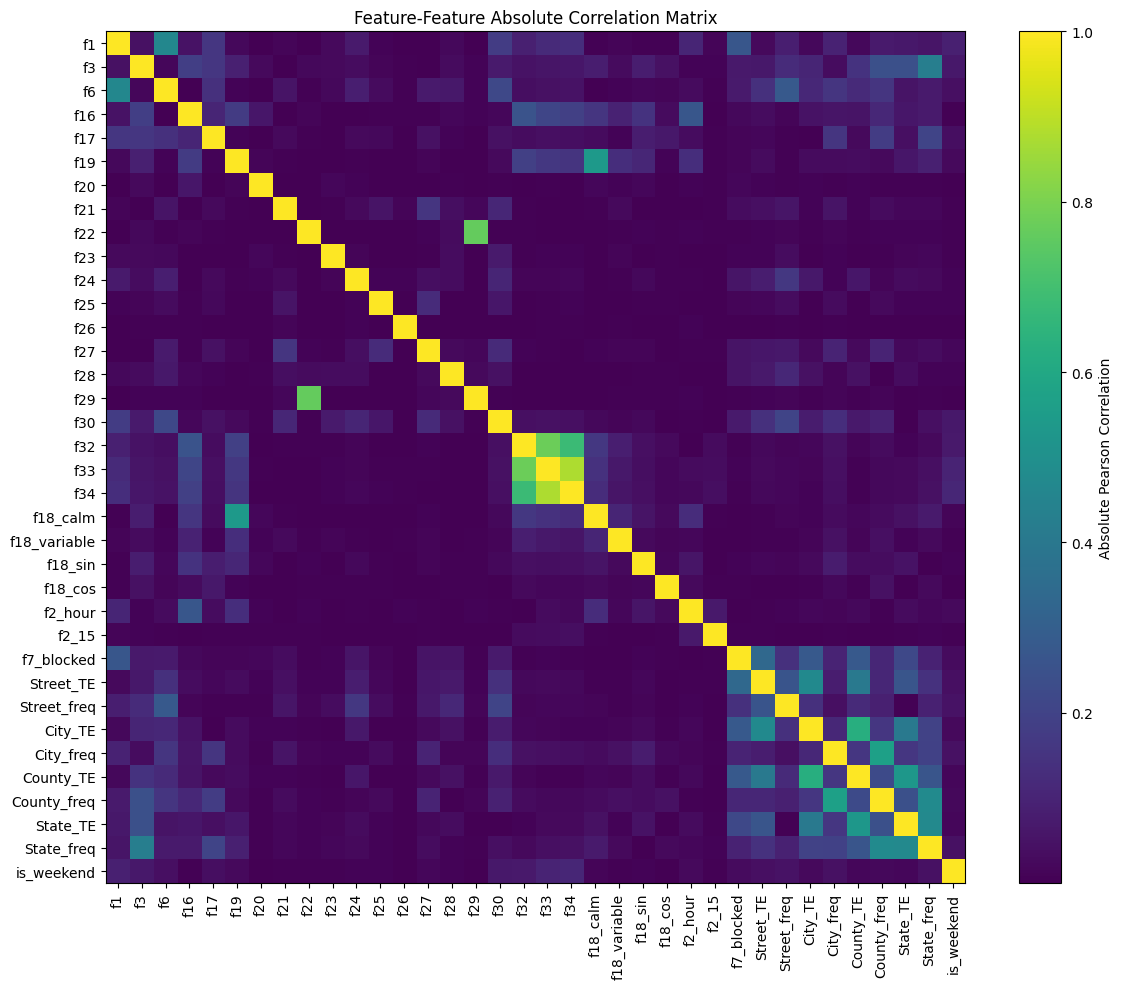

,feature_1,feature_2,abs_corr
477,f33,f34,0.876675


In [208]:
# ============================================================
# 5. EDA: correlation بین featureها
#
# تصمیم:
# اگر abs(correlation) > 0.85 یا 0.90 باشد،
# یعنی دو feature اطلاعات مشابه زیادی دارند.
#
# در این حالت:
# - اگر فقط دو ستون باشند: معمولاً یکی را حذف می‌کنیم.
# - اگر چند ستون یک گروه correlated بسازند: PCA گزینه خوبی است.
# ============================================================

corr_threshold = 0.85

X_train_corr_input = X_train.drop(columns=cols_to_drop_low_variance, errors="ignore")

feature_corr_matrix = X_train_corr_input.corr(method="pearson").abs()

plt.figure(figsize=(12, 10))
plt.imshow(feature_corr_matrix, aspect="auto")
plt.colorbar(label="Absolute Pearson Correlation")
plt.title("Feature-Feature Absolute Correlation Matrix")
plt.xticks(range(len(feature_corr_matrix.columns)), feature_corr_matrix.columns, rotation=90)
plt.yticks(range(len(feature_corr_matrix.columns)), feature_corr_matrix.columns)
plt.tight_layout()
plt.show()

upper_triangle = feature_corr_matrix.where(
    np.triu(np.ones(feature_corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

high_corr_pairs.columns = ["feature_1", "feature_2", "abs_corr"]

high_corr_pairs = high_corr_pairs[
    high_corr_pairs["abs_corr"] >= corr_threshold
].sort_values("abs_corr", ascending=False)

display(high_corr_pairs)

In [209]:
# ============================================================
# 6. پیشنهاد حذف بین featureهای highly correlated
#
# منطق:
# بین دو feature که correlation بالایی دارند،
# featureای را نگه می‌داریم که correlation بیشتری با y دارد.
#
# تصمیم:
# اگر اختلاف ارتباط با y زیاد باشد → حذف feature ضعیف‌تر منطقی است.
# اگر اختلاف کم باشد و هر دو مهم باشند → PCA بهتر است.
# ============================================================

drop_suggestions = []

for _, row in high_corr_pairs.iterrows():
    f1 = row["feature_1"]
    f2 = row["feature_2"]
    
    f1_target_corr = target_corr_df.loc[f1, "abs_corr_with_y"]
    f2_target_corr = target_corr_df.loc[f2, "abs_corr_with_y"]
    
    if f1_target_corr >= f2_target_corr:
        suggested_keep = f1
        suggested_drop = f2
    else:
        suggested_keep = f2
        suggested_drop = f1
    
    drop_suggestions.append({
        "feature_1": f1,
        "feature_2": f2,
        "abs_feature_corr": row["abs_corr"],
        "feature_1_abs_corr_with_y": f1_target_corr,
        "feature_2_abs_corr_with_y": f2_target_corr,
        "suggested_keep": suggested_keep,
        "suggested_drop": suggested_drop
    })

drop_suggestions_df = pd.DataFrame(drop_suggestions)

display(drop_suggestions_df)

suggested_drop_by_corr = (
    drop_suggestions_df["suggested_drop"]
    .value_counts()
    .reset_index()
)

suggested_drop_by_corr.columns = ["feature", "drop_suggestion_count"]

display(suggested_drop_by_corr)

,feature_1,feature_2,abs_feature_corr,feature_1_abs_corr_with_y,feature_2_abs_corr_with_y,suggested_keep,suggested_drop
0,f33,f34,0.876675,0.005022,0.008135,f34,f33


,feature,drop_suggestion_count
0,f33,1


In [210]:
# ============================================================
# 7. ساخت گروه‌های correlated برای PCA
#
# اگر featureها به شکل زنجیره‌ای با هم correlation بالا داشته باشند،
# آن‌ها را در یک گروه قرار می‌دهیم.
#
# مثال:
# A با B correlated است
# B با C correlated است
# پس A, B, C یک گروه می‌شوند.
# ============================================================

def find_correlated_groups(high_corr_pairs):
    graph = {}

    for _, row in high_corr_pairs.iterrows():
        f1 = row["feature_1"]
        f2 = row["feature_2"]

        graph.setdefault(f1, set()).add(f2)
        graph.setdefault(f2, set()).add(f1)

    visited = set()
    groups = []

    for node in graph:
        if node not in visited:
            stack = [node]
            group = set()

            while stack:
                current = stack.pop()
                if current not in visited:
                    visited.add(current)
                    group.add(current)
                    stack.extend(graph[current] - visited)

            if len(group) >= 2:
                groups.append(sorted(group))

    return groups


correlated_groups = find_correlated_groups(high_corr_pairs)

print("Correlated groups:")
for i, group in enumerate(correlated_groups, start=1):
    print(f"Group {i}:", group)

Correlated groups:
Group 1: ['f33', 'f34']


In [211]:
# ============================================================
# 8. تصمیم‌گیری برای هر گروه correlated
#
# قانون پیشنهادی:
#
# اگر گروه فقط 2 ستون دارد و یکی از آن‌ها correlation بیشتری با y دارد:
#   حذف ستون ضعیف‌تر معمولاً ساده‌تر و قابل توضیح‌تر است.
#
# اگر گروه 3 ستون یا بیشتر دارد:
#   PCA مناسب‌تر است، چون اطلاعات کل گروه را فشرده می‌کند.
#
# اگر تفسیرپذیری خیلی مهم است:
#   حذف feature بهتر از PCA است.
#
# اگر performance مهم‌تر از تفسیرپذیری است:
#   PCA روی گروه correlated مناسب است.
# ============================================================

pca_candidate_groups = []
drop_candidate_cols = []

target_corr_difference_threshold = 0.01

for group in correlated_groups:
    group_target_corr = target_corr_df.loc[group, "abs_corr_with_y"].sort_values(ascending=False)
    
    print("\nGroup:")
    print(group)
    display(group_target_corr.to_frame("abs_corr_with_y"))
    
    if len(group) >= 3:
        pca_candidate_groups.append(group)
    else:
        best_feature = group_target_corr.index[0]
        second_feature = group_target_corr.index[1]
        
        diff = group_target_corr.iloc[0] - group_target_corr.iloc[1]
        
        if diff >= target_corr_difference_threshold:
            drop_candidate_cols.append(second_feature)
        else:
            pca_candidate_groups.append(group)

print("PCA candidate groups:")
print(pca_candidate_groups)

print("Drop candidate columns based on high correlation:")
print(drop_candidate_cols)


Group:
['f33', 'f34']


,abs_corr_with_y
f34,0.008135
f33,0.005022


PCA candidate groups:
[['f33', 'f34']]
Drop candidate columns based on high correlation:
[]


In [212]:
# ============================================================
# 9. PCA دستی با numpy
#
# این تابع:
# - mean و std را فقط از train محاسبه می‌کند
# - PCA را فقط روی train fit می‌کند
# - سپس همان transformation را روی train و test اعمال می‌کند
#
# n_components به شکلی انتخاب می‌شود که حداقل 95 درصد variance حفظ شود.
# ============================================================

def fit_pca_numpy(X, variance_threshold=0.95):
    X = X.copy()
    
    mean = X.mean(axis=0)
    std = X.std(axis=0, ddof=1)
    std[std == 0] = 1
    
    X_scaled = (X - mean) / std
    
    U, S, Vt = np.linalg.svd(X_scaled, full_matrices=False)
    
    explained_variance = (S ** 2) / (len(X_scaled) - 1)
    explained_variance_ratio = explained_variance / explained_variance.sum()
    cumulative_variance_ratio = np.cumsum(explained_variance_ratio)
    
    n_components = np.searchsorted(cumulative_variance_ratio, variance_threshold) + 1
    
    components = Vt[:n_components]
    
    pca_params = {
        "mean": mean,
        "std": std,
        "components": components,
        "explained_variance_ratio": explained_variance_ratio[:n_components],
        "cumulative_variance_ratio": cumulative_variance_ratio[:n_components],
        "n_components": n_components
    }
    
    return pca_params


def transform_pca_numpy(X, pca_params):
    X = X.copy()
    X_scaled = (X - pca_params["mean"]) / pca_params["std"]
    X_pca = np.dot(X_scaled, pca_params["components"].T)
    return X_pca


# ============================================================
# 10. اعمال PCA روی گروه‌های انتخاب‌شده
# ============================================================

train_pca_ready = train_processed.copy()
test_pca_ready = test_processed.copy()

pca_models = {}
pca_created_cols = []
pca_removed_cols = []

variance_threshold = 0.95

for group_idx, group_cols in enumerate(pca_candidate_groups, start=1):
    group_cols = [
        col for col in group_cols
        if col in train_pca_ready.columns and col in test_pca_ready.columns
    ]
    
    if len(group_cols) < 2:
        continue
    
    train_group = train_pca_ready[group_cols].copy()
    test_group = test_pca_ready[group_cols].copy()
    
    pca_params = fit_pca_numpy(
        train_group,
        variance_threshold=variance_threshold
    )
    
    train_group_pca = transform_pca_numpy(train_group, pca_params)
    test_group_pca = transform_pca_numpy(test_group, pca_params)
    
    new_cols = [
        f"pca_group{group_idx}_pc{i+1}"
        for i in range(pca_params["n_components"])
    ]
    
    train_group_pca_df = pd.DataFrame(
        train_group_pca,
        columns=new_cols,
        index=train_pca_ready.index
    )
    
    test_group_pca_df = pd.DataFrame(
        test_group_pca,
        columns=new_cols,
        index=test_pca_ready.index
    )
    
    train_pca_ready = pd.concat([train_pca_ready, train_group_pca_df], axis=1)
    test_pca_ready = pd.concat([test_pca_ready, test_group_pca_df], axis=1)
    
    train_pca_ready = train_pca_ready.drop(columns=group_cols)
    test_pca_ready = test_pca_ready.drop(columns=group_cols)
    
    pca_models[f"group_{group_idx}"] = {
        "original_features": group_cols,
        "new_features": new_cols,
        "pca_params": pca_params
    }
    
    pca_created_cols.extend(new_cols)
    pca_removed_cols.extend(group_cols)

print("PCA created columns:")
print(pca_created_cols)

print("PCA removed original columns:")
print(pca_removed_cols)

for group_name, model_info in pca_models.items():
    print("\n", group_name)
    print("Original features:", model_info["original_features"])
    print("New PCA features:", model_info["new_features"])
    print("Explained variance ratio:", model_info["pca_params"]["explained_variance_ratio"])
    print("Cumulative variance ratio:", model_info["pca_params"]["cumulative_variance_ratio"])

PCA created columns:
['pca_group1_pc1', 'pca_group1_pc2']
PCA removed original columns:
['f33', 'f34']

 group_1
Original features: ['f33', 'f34']
New PCA features: ['pca_group1_pc1', 'pca_group1_pc2']
Explained variance ratio: [0.93833731 0.06166269]
Cumulative variance ratio: [0.93833731 1.        ]


In [213]:
# ============================================================
# 11. حذف featureهای low variance و featureهای پیشنهادی correlation
#
# اگر PCA اعمال شده باشد، ستون‌های original آن گروه‌ها قبلاً حذف شده‌اند.
# اینجا فقط ستون‌هایی حذف می‌شوند که هنوز وجود دارند.
# ============================================================

cols_to_drop_final = sorted(
    set(cols_to_drop_low_variance + highly_imbalanced_binary_cols + drop_candidate_cols)
)

train_selected = train_pca_ready.drop(columns=cols_to_drop_final, errors="ignore")
test_selected = test_pca_ready.drop(columns=cols_to_drop_final, errors="ignore")

print("Dropped columns:")
print(cols_to_drop_final)

print("Final train_selected shape:", train_selected.shape)
print("Final test_selected shape:", test_selected.shape)

display(train_selected.head())

Dropped columns:
['f22', 'f23', 'f26', 'f29', 'f31']
Final train_selected shape: (79962, 33)
Final test_selected shape: (19982, 33)


,f1,f3,f6,f16,f17,f19,f20,f21,f24,f25,...,Street_freq,City_TE,City_freq,County_TE,County_freq,State_TE,State_freq,is_weekend,pca_group1_pc1,pca_group1_pc2
0,1,1.240554,-0.687501,1.246846,-0.743122,-0.101333,-0.064727,0,0,0,...,-1.145501,0.337961,-0.536633,0.652932,-0.553300,1.203780,-1.348737,0,-0.685716,-0.042814
1,2,0.913001,-0.687501,-0.254217,1.442080,-0.190337,-0.064727,0,0,0,...,-0.356237,-0.510536,1.301436,-0.730095,0.782022,-0.848367,-0.062531,0,2.928037,-0.182819
2,1,-1.553757,0.386541,-1.755280,-0.168069,0.328808,-0.064727,0,0,0,...,-1.145501,-0.824332,-0.518551,-1.242127,-0.950105,-0.465490,1.310527,0,-0.685716,-0.042814
3,1,1.201419,-0.642052,1.246846,0.023615,-0.961614,0.049387,0,0,0,...,1.627936,0.712477,0.225282,0.966563,-0.549166,0.489541,-0.058224,1,2.928037,-0.182819
4,2,-1.556845,-0.663581,0.496314,0.272805,2.113891,-0.064727,0,0,0,...,0.500085,-0.865238,-0.002116,-1.255390,-0.399493,-0.465490,1.310527,1,-0.685716,-0.042814
